# E628: Data Science for Business with Python
## Session 7: Machine Learning
### Author: Kostis Christodoulou
### Date: 2026-03-07

---

# Introduction to Machine Learning

## What is machine learning?

Machine learning is a field of artificial intelligence that enables computers to learn from data without being explicitly programmed. Instead of followbirthweighting rigid instructions, ML algorithms identify patterns and make decisions based on examples.

![Machine Learning Comic](https://imgs.xkcd.com/comics/machine_learning.png)

[Source: xkcd.com/1838/](https://xkcd.com/1838/)

## Two types of questions

- **Classification**: Will this house sell in the next 30 days?
- **Regression**: What will be the sale price for this house?

## What is the goal of machine learning?

Build **models** that generate **accurate predictions** for **future, yet-to-be-seen data**.

# Setup and Data Loading

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    roc_curve, classification_report
)
from sklearn.model_selection import cross_validate  # Import for multi-metric support

# if you have a mac, you need to run `brew install libomp` and restart your kernel
# this will install OpenMP (Open Multi-Processing) to handle parallel computing on macOS
from lightgbm import LGBMClassifier           # Import the Light Gradient Boosting Machine classifier 
from xgboost import XGBClassifier

import shap

import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Load the ncbirths dataset
# ncbirths = pd.read_csv('../data/smoking_birth_weight.csv')

ncbirths = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/smoking_birth_weight.csv")


# Rename columns 
ncbirths = ncbirths.rename(columns={
    'lowbirthweight': 'low', 
    'habit': 'smoke'
})

# Convert categorical variables
ncbirths['low'] = ncbirths['low'].astype('category')
ncbirths['smoke'] = ncbirths['smoke'].astype('category')

# Display basic information
print(f"Dataset shape: {ncbirths.shape}")
print(f"\nColumn types:\n{ncbirths.dtypes}")
print(f"\nFirst few rows:")
ncbirths.head()


Dataset shape: (1000, 12)

Column types:
father_age     float64
mother_age       int64
mature          object
weeks          float64
preterm         object
visits         float64
low           category
gender          object
smoke         category
whitemom        object
weight_kg      float64
gained_kg      float64
dtype: object

First few rows:


,father_age,mother_age,mature,weeks,preterm,visits,low,gender,smoke,whitemom,weight_kg,gained_kg
0,NaN,13,younger mom,39.0,full term,10.0,not low,male,nonsmoker,not white,3.46402,17.272727
1,NaN,14,younger mom,42.0,full term,15.0,not low,male,nonsmoker,not white,3.57752,9.090909
2,19.0,15,younger mom,37.0,full term,11.0,not low,female,nonsmoker,white,3.01002,17.272727
3,21.0,15,younger mom,41.0,full term,6.0,not low,male,nonsmoker,white,3.63200,15.454545
4,NaN,15,younger mom,39.0,full term,9.0,not low,female,nonsmoker,not white,2.89652,12.272727


# Exploratory Data Analysis

## Smoking and Birth Weight

The `ncbirths` dataset contains 1,000 birth records from North Carolina in 2001.

**Information about the birth:**
- Single, twin, or triplet birth
- Number of completed weeks of gestation
- Whether the birth is premature (<36 weeks)

**Information about the baby:**
- Sex
- Weight at birth
- Whether birth weight is considered low (<2500 grams)

**Information about the mother:**
- Age
- Weight gained during pregnancy
- Whether she is a smoker

In [6]:
# Summary statistics
print("Dataset Summary:")
print(ncbirths.describe().T)

print("\nMissing values:")
print(ncbirths.isnull().sum())

Dataset Summary:
             count       mean       std     min        25%        50%  \
father_age   829.0  30.255730  6.763766  14.000  25.000000  30.000000   
mother_age  1000.0  27.000000  6.213583  13.000  22.000000  27.000000   
weeks        998.0  38.334669  2.931553  20.000  37.000000  39.000000   
visits       991.0  12.104945  3.954934   0.000  10.000000  12.000000   
weight_kg   1000.0   3.223854  0.685023   0.454   2.896520   3.318740   
gained_kg    973.0  13.784453  6.473317   0.000   9.090909  13.636364   

                  75%        max  
father_age  35.000000  55.000000  
mother_age  32.000000  50.000000  
weeks       40.000000  45.000000  
visits      15.000000  30.000000  
weight_kg    3.659240   5.334500  
gained_kg   17.272727  38.636364  

Missing values:
father_age    171
mother_age      0
mature          0
weeks           2
preterm         2
visits          9
low             0
gender          0
smoke           1
whitemom        2
weight_kg       0
gained_kg  

## Visualizing the Data

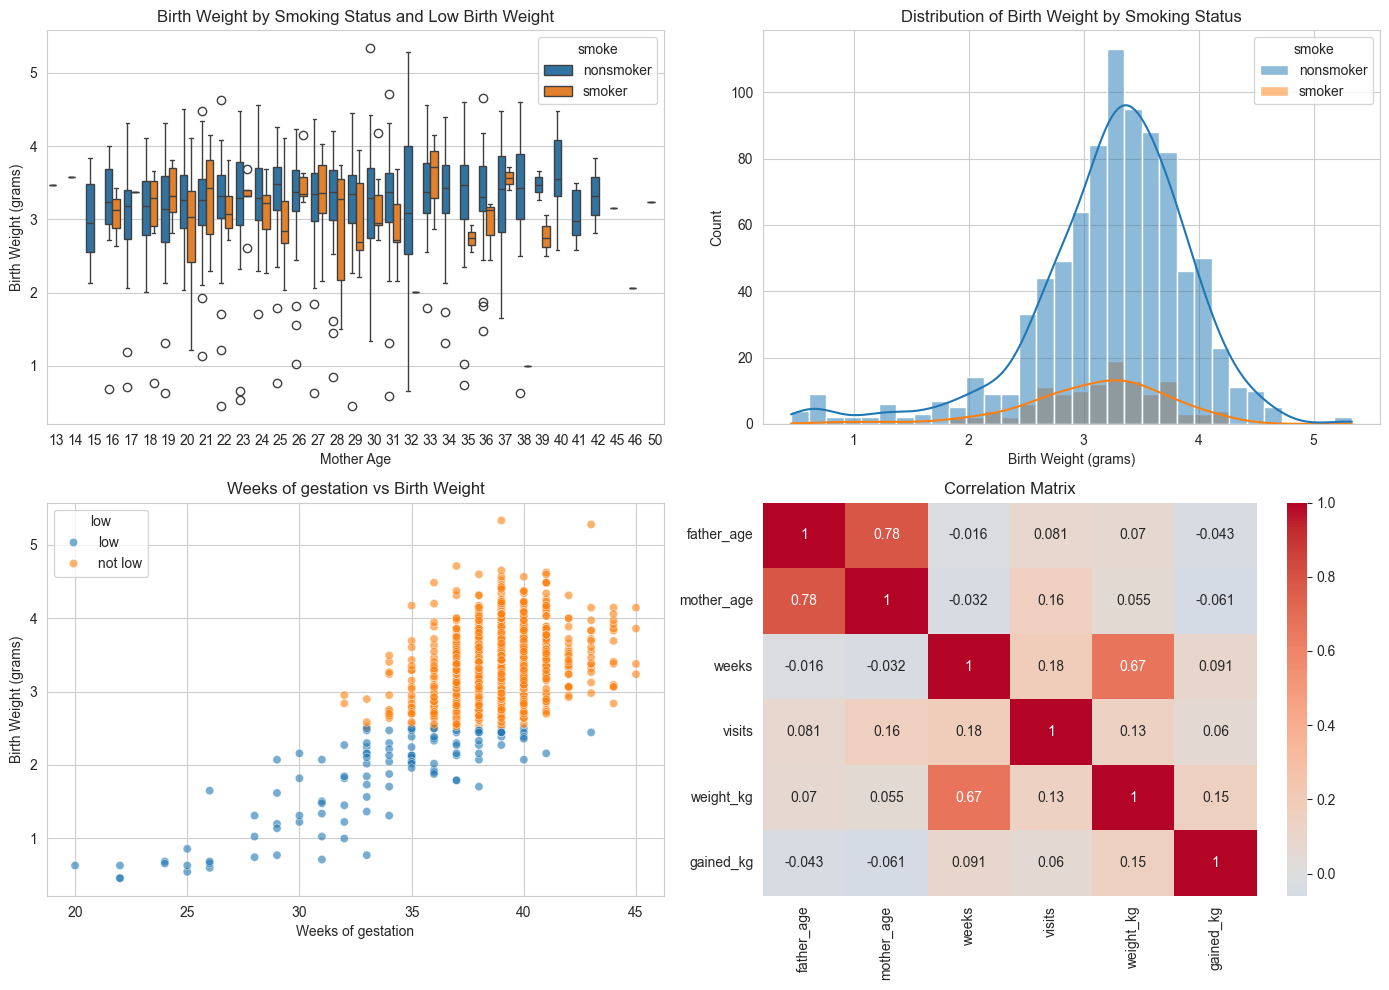

In [36]:
# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of birth weight by smoking status
sns.boxplot(
    data=ncbirths, 
    x='mother_age', 
    y='weight_kg', 
    hue='smoke',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Birth Weight by Smoking Status and Low Birth Weight')
axes[0, 0].set_xlabel('Mother Age')
axes[0, 0].set_ylabel('Birth Weight (grams)')

# 2. Distribution of birth weight by smoking status
sns.histplot(
    data=ncbirths, 
    x='weight_kg', 
    hue='smoke', 
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Distribution of Birth Weight by Smoking Status')
axes[0, 1].set_xlabel('Birth Weight (grams)')

# 3. Mother's age vs birth weight
sns.scatterplot(
    data=ncbirths, 
    x='weeks', 
    y='weight_kg', 
    hue='low',
    alpha=0.6,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Weeks of gestation vs Birth Weight')
axes[1, 0].set_xlabel('Weeks of gestation')
axes[1, 0].set_ylabel('Birth Weight (grams)')

# 4. Correlation heatmap (numeric variables only)
numeric_cols = ncbirths.select_dtypes(include=[np.number]).columns
correlation_matrix = ncbirths[numeric_cols].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Data Splitting and Resampling

## Data Budget

For machine learning, we typically split data (e.g., 80%-20%) into training and test sets:

- **Training set** is used to estimate model parameters
- **Test set** is used to get an independent assessment of model efficacy

**Important**: Do not use test data during training!

## Create Train-Test Split

In [3]:
# =============================================================================
#  DATA PREPARATION & CLEANING
# =============================================================================

# Fix the random seed to ensure the split is identical every time the code runs
np.random.seed(123)

# Remove rows with missing values to ensure a clean dataset
ncbirths_clean = ncbirths.dropna()

# Map the target (y) to binary integers: 'low' birthweight is our positive event (1)
# This mapping is essential to prevent "NaN" in F1, Precision, and Recall metrics
y = ncbirths_clean['low'].map({'low': 1, 'not low': 0})

# Identify columns to exclude: the target ('low') and leaky features ('weight_kg')
# Weight_kg is dropped because it is a direct proxy for the 'low' status
cols_to_exclude = ['low', 'weight_kg']

# Create the feature matrix X by dropping the target and leaky variables
X = ncbirths_clean.drop(columns=cols_to_exclude)


# =============================================================================
# STRATIFIED TRAIN-TEST SPLIT
# =============================================================================

# Divide the data into training (80%) and testing (20%) subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,                                     # Feature set
    y,                                     # Target labels
    test_size=0.20,                        # Reserve 20% of the data for testing
    random_state=123,                      # Seed for the internal shuffling logic
    stratify=y                             # Keep the 'low' birthweight ratio consistent, about 9%
)

# =============================================================================
# 3. SUMMARY AND VERIFICATION
# =============================================================================

# Display total counts using f-string formatting with commas for readability
print(f"Observations in Training Set : {len(X_train):,}")
print(f"Observations in Test Set     : {len(X_test):,}")

# Print a header for the class balance check
print("\nClass Distribution (Target = 'low'):")

# Calculate percentage distribution and print each class with 2 decimal places
distribution = y_train.value_counts(normalize=True).mul(100)
for category, percentage in distribution.items():
    print(f"  - {category}: {percentage:.2f}%")

Observations in Training Set : 640
Observations in Test Set     : 160

Class Distribution (Target = 'low'):
  - 0: 90.78%
  - 1: 9.22%


# Logistic Regression for Beginners

## What problem does it solve?

We want to predict a **yes/no outcome** — in our case, whether a baby's birth weight is *low* or *not low*.

Linear regression predicts a continuous number, which could land outside [0, 1] and is hard to interpret as a probability. **Logistic regression** squashes any linear combination of inputs through the **sigmoid (S-shaped) function** to always output a value between 0 and 1.

$$P(y=1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p)}}$$

The model outputs a **probability**. We then apply a **decision threshold** (default = 0.5) to convert that probability into a class label:

| Predicted probability | Decision (threshold = 0.5) |
|---|---|
| ≥ 0.5 | Predict **low** birth weight |
| < 0.5 | Predict **not low** birth weight |

> **Why does the threshold matter?**  
> Raising the threshold makes the model more conservative (fewer "low" predictions → fewer False Positives, but more False Negatives). Lowering it catches more true positives but also flags more healthy babies as at-risk.

---


In [ ]:
# =============================================================================
# LOGISTIC REGRESSION: FIT A SIMPLE MODEL ON ONE FEATURE
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import Slider
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# ── 1. Prepare a clean 1-feature dataset (weeks gestation) ──────────────────
df_lr = ncbirths[['weeks', 'low']].dropna().copy()
df_lr['low_binary'] = (df_lr['low'].astype(str) == 'low').astype(int)

X_lr = df_lr[['weeks']].values
y_lr = df_lr['low_binary'].values

# ── 2. Fit the model ─────────────────────────────────────────────────────────
lr_simple = LogisticRegression()
lr_simple.fit(X_lr, y_lr)

# ── 3. Smooth S-curve ────────────────────────────────────────────────────────
x_range   = np.linspace(X_lr.min() - 1, X_lr.max() + 1, 400).reshape(-1, 1)
prob_curve = lr_simple.predict_proba(x_range)[:, 1]

# ── 4. Per-observation probabilities ─────────────────────────────────────────
probs_obs = lr_simple.predict_proba(X_lr)[:, 1]

print(f"Logistic Regression coefficient (weeks): {lr_simple.coef_[0][0]:.4f}")
print(f"Intercept: {lr_simple.intercept_[0]:.4f}")
print(f"\nInterpretation: For each additional week of gestation, the")
print(f"log-odds of low birth weight change by {lr_simple.coef_[0][0]:.4f}.")


Logistic Regression coefficient (weeks): -0.7047
Intercept: 24.0030

Interpretation: For each additional week of gestation, the
log-odds of low birth weight change by -0.7047.


In [ ]:
# =============================================================================
# INTERACTIVE S-CURVE: ADJUST THE DECISION THRESHOLD
# =============================================================================
# Uses ipywidgets (already in Jupyter) — no extra backend needed.
# Points are coloured by classification outcome:
#   🟢 True Positive   (correctly flagged as low birthweight)
#   🔵 True Negative   (correctly flagged as not low)
#   🔴 False Positive  (flagged as low — but baby was healthy)
#   🟠 False Negative  (missed — baby was low but model said healthy)

%matplotlib inline
import ipywidgets as widgets
from IPython.display import display

COLORS = {
    'TP': '#2ecc71',   # green
    'TN': '#3498db',   # blue
    'FP': '#e74c3c',   # red
    'FN': '#f39c12',   # orange
}
LABELS = {
    'TP': 'True Positive (correctly caught low BW)',
    'TN': 'True Negative (correctly cleared)',
    'FP': 'False Positive (false alarm)',
    'FN': 'False Negative (missed case)',
}

def classify(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)
    cats  = []
    for p, l in zip(preds, labels):
        if   p == 1 and l == 1: cats.append('TP')
        elif p == 0 and l == 0: cats.append('TN')
        elif p == 1 and l == 0: cats.append('FP')
        else:                   cats.append('FN')
    return cats

rng      = np.random.default_rng(42)
jitter_y = rng.uniform(-0.015, 0.015, len(probs_obs))
jitter_x = rng.uniform(-0.3,   0.3,   len(probs_obs))

def plot_scurve(threshold=0.5):
    cats = classify(probs_obs, y_lr, threshold)
    
    fig, ax = plt.subplots(figsize=(11, 6))

    # S-curve
    ax.plot(x_range, prob_curve, color='#2c3e50', lw=2.5, zorder=2,
            label='P(low | weeks)')

    # Threshold line
    ax.axhline(threshold, color='#8e44ad', lw=2, linestyle='--',
               label=f'Threshold = {threshold:.2f}')

    # Scatter — 4 colours
    for cat in ['TP', 'TN', 'FP', 'FN']:
        idx = [i for i, c in enumerate(cats) if c == cat]
        if idx:
            ax.scatter(
                X_lr[idx].flatten() + jitter_x[idx],
                probs_obs[idx] + jitter_y[idx],
                c=COLORS[cat], s=45, alpha=0.80, zorder=4,
                label=f'{cat} — {LABELS[cat]}  (n={len(idx)})'
            )

    # Stats box
    c         = {k: cats.count(k) for k in ['TP','TN','FP','FN']}
    precision = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) > 0 else 0
    recall    = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) > 0 else 0
    stats = (f"TP={c['TP']}  TN={c['TN']}  FP={c['FP']}  FN={c['FN']}\n"
             f"Precision = {precision:.2f}   Recall = {recall:.2f}")
    ax.text(0.02, 0.92, stats, transform=ax.transAxes, fontsize=10,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

    ax.set_xlabel('Weeks of Gestation', fontsize=13)
    ax.set_ylabel('Predicted Probability of Low Birth Weight', fontsize=13)
    ax.set_title('Logistic Regression — S-Curve with Adjustable Decision Threshold',
                 fontsize=14)
    ax.set_ylim(-0.06, 1.06)
    ax.set_xlim(float(x_range.min()), float(x_range.max()))
    ax.legend(loc='upper right', framealpha=0.92, fontsize=9.5, bbox_to_anchor=(1.0, 0.92))
    plt.tight_layout()
    plt.show()

slider = widgets.FloatSlider(
    value=0.5, min=0.01, max=0.99, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

widgets.interact(plot_scurve, threshold=slider)


interactive(children=(FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='60%'), max=0.99, m…

<function __main__.plot_scurve(threshold=0.5)>

## Reading the interactive plot

| Colour | Label | Meaning |
|--------|-------|---------|
| 🟢 Green  | **True Positive (TP)**  | Model predicted *low* — and it **was** low. Correct! |
| 🔵 Blue   | **True Negative (TN)**  | Model predicted *not low* — and it **was not** low. Correct! |
| 🔴 Red    | **False Positive (FP)** | Model predicted *low* — but baby was healthy. Unnecessary alarm. |
| 🟠 Orange | **False Negative (FN)** | Model predicted *not low* — but baby was actually low weight. **Missed case.** |

### What happens when you move the slider?

- **Raise the threshold** → model becomes more conservative: fewer FP, but more FN (miss real cases).
- **Lower the threshold** → model catches more true cases: fewer FN, but more FP (false alarms).

In a clinical setting, missing a low-birthweight baby (FN) is usually more costly than a false alarm (FP), so practitioners often **lower the threshold** below 0.5.

---


## ROC Curve — Interactive Threshold

The **Receiver Operating Characteristic (ROC) curve** plots the trade-off between:

- **True Positive Rate (Recall / Sensitivity)** = TP / (TP + FN) — how many actual positives we catch
- **False Positive Rate** = FP / (FP + TN) — how many healthy cases we wrongly flag

Three reference lines help you read it:

| Line | Meaning |
|------|---------|
| ⬛ Bold L-shaped line | **Perfect classifier** — hugs the top-left corner (FPR=0, TPR=1) |
| ‐ ‐ Grey diagonal | **Random classifier** (flipping a coin) — AUC = 0.50 |
| 🟣 Dot on curve | **Current threshold** — drag the slider to move it |

The **AUC (Area Under Curve)** summarises overall performance: 1.0 is perfect, 0.5 is random.


In [26]:
# =============================================================================
# INTERACTIVE ROC CURVE WITH ADJUSTABLE THRESHOLD
# =============================================================================

from sklearn.metrics import roc_curve, auc

# Compute the full ROC curve from our simple logistic regression
fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_lr, probs_obs, pos_label=1)
roc_auc = auc(fpr_arr, tpr_arr)

def plot_roc(threshold=0.5):
    # Find the point on the ROC curve closest to this threshold
    diffs = np.abs(thresholds_arr - threshold)
    idx   = np.argmin(diffs)
    pt_fpr, pt_tpr = fpr_arr[idx], tpr_arr[idx]

    # Recompute counts at this threshold for the annotation
    cats      = classify(probs_obs, y_lr, threshold)
    c         = {k: cats.count(k) for k in ['TP','TN','FP','FP','FN']}
    c         = {k: cats.count(k) for k in ['TP','TN','FP','FN']}
    precision = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) > 0 else 0
    recall    = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) > 0 else 0

    fig, ax = plt.subplots(figsize=(8, 7))

    # ── Random classifier (coin flip) ─────────────────────────────────────
    ax.plot([0, 1], [0, 1], linestyle='--', color='#95a5a6', lw=1.8,
            label='Random classifier  (AUC = 0.50)', zorder=1)

    # ── Perfect classifier ────────────────────────────────────────────────
    ax.plot([0, 0, 1], [0, 1, 1], linestyle='-', color='#2c3e50', lw=3,
            label='Perfect classifier  (AUC = 1.00)', zorder=2)

    # ── Actual ROC curve ──────────────────────────────────────────────────
    ax.plot(fpr_arr, tpr_arr, color='#8e44ad', lw=2.5,
            label=f'Logistic Regression  (AUC = {roc_auc:.3f})', zorder=3)

    # Fill area under actual curve
    ax.fill_between(fpr_arr, tpr_arr, alpha=0.08, color='#8e44ad', zorder=0)

    # ── Current threshold marker ──────────────────────────────────────────
    ax.scatter([pt_fpr], [pt_tpr], s=160, color='#e74c3c', zorder=5,
               label=f'Threshold = {threshold:.2f}  (FPR={pt_fpr:.2f}, TPR={pt_tpr:.2f})')

    # Dotted drop-lines to axes
    ax.plot([pt_fpr, pt_fpr], [0, pt_tpr], ':', color='#e74c3c', lw=1.2, zorder=4)
    ax.plot([0, pt_fpr],      [pt_tpr, pt_tpr], ':', color='#e74c3c', lw=1.2, zorder=4)

    # ── Stats box ─────────────────────────────────────────────────────────
    stats = (f"TP={c['TP']}  TN={c['TN']}  FP={c['FP']}  FN={c['FN']}\n"
             f"Precision = {precision:.2f}   Recall = {recall:.2f}")
    ax.text(0.52, 0.18, stats, transform=ax.transAxes, fontsize=10,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

    ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=13)
    ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=13)
    ax.set_title('ROC Curve — Logistic Regression\n(drag slider to move the threshold)',
                 fontsize=14)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='lower right', framealpha=0.92, fontsize=10)
    plt.tight_layout()
    plt.show()

roc_slider = widgets.FloatSlider(
    value=0.5, min=0.01, max=0.99, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

widgets.interact(plot_roc, threshold=roc_slider)


interactive(children=(FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='60%'), max=0.99, m…

<function __main__.plot_roc(threshold=0.5)>

## Reading the interactive plot

| Colour | Label | Meaning |
|--------|-------|---------|
| 🟢 Green  | **True Positive (TP)**  | Model predicted *low* — and it **was** low. Correct! |
| 🔵 Blue   | **True Negative (TN)**  | Model predicted *not low* — and it **was not** low. Correct! |
| 🔴 Red    | **False Positive (FP)** | Model predicted *low* — but baby was healthy. Unnecessary alarm. |
| 🟠 Orange | **False Negative (FN)** | Model predicted *not low* — but baby was actually low weight. **Missed case.** |

### What happens when you move the slider?

- **Raise the threshold** → model becomes more conservative: fewer FP, but more FN (miss real cases).
- **Lower the threshold** → model catches more true cases: fewer FN, but more FP (false alarms).

In a clinical setting, missing a low-birthweight baby (FN) is usually more costly than a false alarm (FP), so practitioners often **lower the threshold** below 0.5.

---


## Links

For a great interactive discussion of logistic regression, precision-recall, and ROC curves, check out:

- [Logistic Regression](https://mlu-explain.github.io/logistic-regression/) 
- [Precision-Recall](https://mlu-explain.github.io/precision-recall)
- [ROC Curve](https://mlu-explain.github.io/roc-auc/)

# Feature Engineering and Preprocessing

In [28]:
# =============================================================================
#  AUTOMATED FEATURE IDENTIFICATION
# =============================================================================

# Filter the training data for object/category types and extract their column names as a list
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Filter the training data for numeric types (int/float) and extract their column names as a list
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Output the results to verify that the automated detection correctly mapped the variables
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features   ({len(numerical_features)}): {numerical_features}")

# =============================================================================
# 5. DEFINING TRANSFORMER PIPELINES
# =============================================================================

# Define the workflow for numeric data: Scale values to a mean of 0 and variance of 1
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())           # Apply Z-score normalization to ensure features share the same scale
])

# Define the workflow for categorical data: Convert labels into binary (dummy) variables
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(              # Initialize the One-Hot Encoder
        drop='first',                      # Drop the first category to avoid multi-collinearity (the 'Dummy Variable Trap')
        sparse_output=False                # Return a dense array for easier inspection and model compatibility
    ))
])

# =============================================================================
# 6. ORCHESTRATING THE COLUMN TRANSFORMER
# =============================================================================

# Construct the master preprocessor to apply specific logic to specific columns simultaneously
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),  # Apply the scaling pipeline to numeric columns
        ('cat', categorical_transformer, categorical_features) # Apply the encoding pipeline to categorical columns
    ]
)

# Confirmation message to signal the preprocessing architecture is ready for the model
print("\n[SUCCESS] Preprocessing pipeline constructed and ready for data fitting.")

Categorical features (5): ['mature', 'preterm', 'gender', 'smoke', 'whitemom']
Numerical features   (5): ['father_age', 'mother_age', 'weeks', 'visits', 'gained_kg']

[SUCCESS] Preprocessing pipeline constructed and ready for data fitting.


# Decision Tree and Visualisation for Beginners

## What problem does it solve?

We want to predict a **yes/no outcome** — in our case, whether a baby's birth weight is *low* or *not low*.

Linear regression predicts a continuous number, which could land outside [0, 1] and is hard to interpret as a probability. **Logistic regression** squashes any linear combination of inputs through the **sigmoid (S-shaped) function** to always output a value between 0 and 1.


- Trees do not assume a certain model for or a distribution of the underlying data. Therefore, they are a *nonparametric* method.
-   Interpretable: Output is a set of rules that can be compared and combined with intuition.
-   They are displayed as trees, hence the name
-   In regression trees, Impurity is measured by the Sum of Squared Errors (SSE) from the node mean
-   In classification trees, Impurity is measured by the Gini Index or Entropy


## How the decision tree algorithm works
At each split the algorithm tries every possible cut and picks the one that reduces Gini the most (called the Gini gain). So the tree is essentially asking at every node: "which feature and threshold makes the two child nodes as pure as possible?"
That's why num__weeks <= 35.5 is at the very top — it gave the biggest purity improvement across the whole training set.


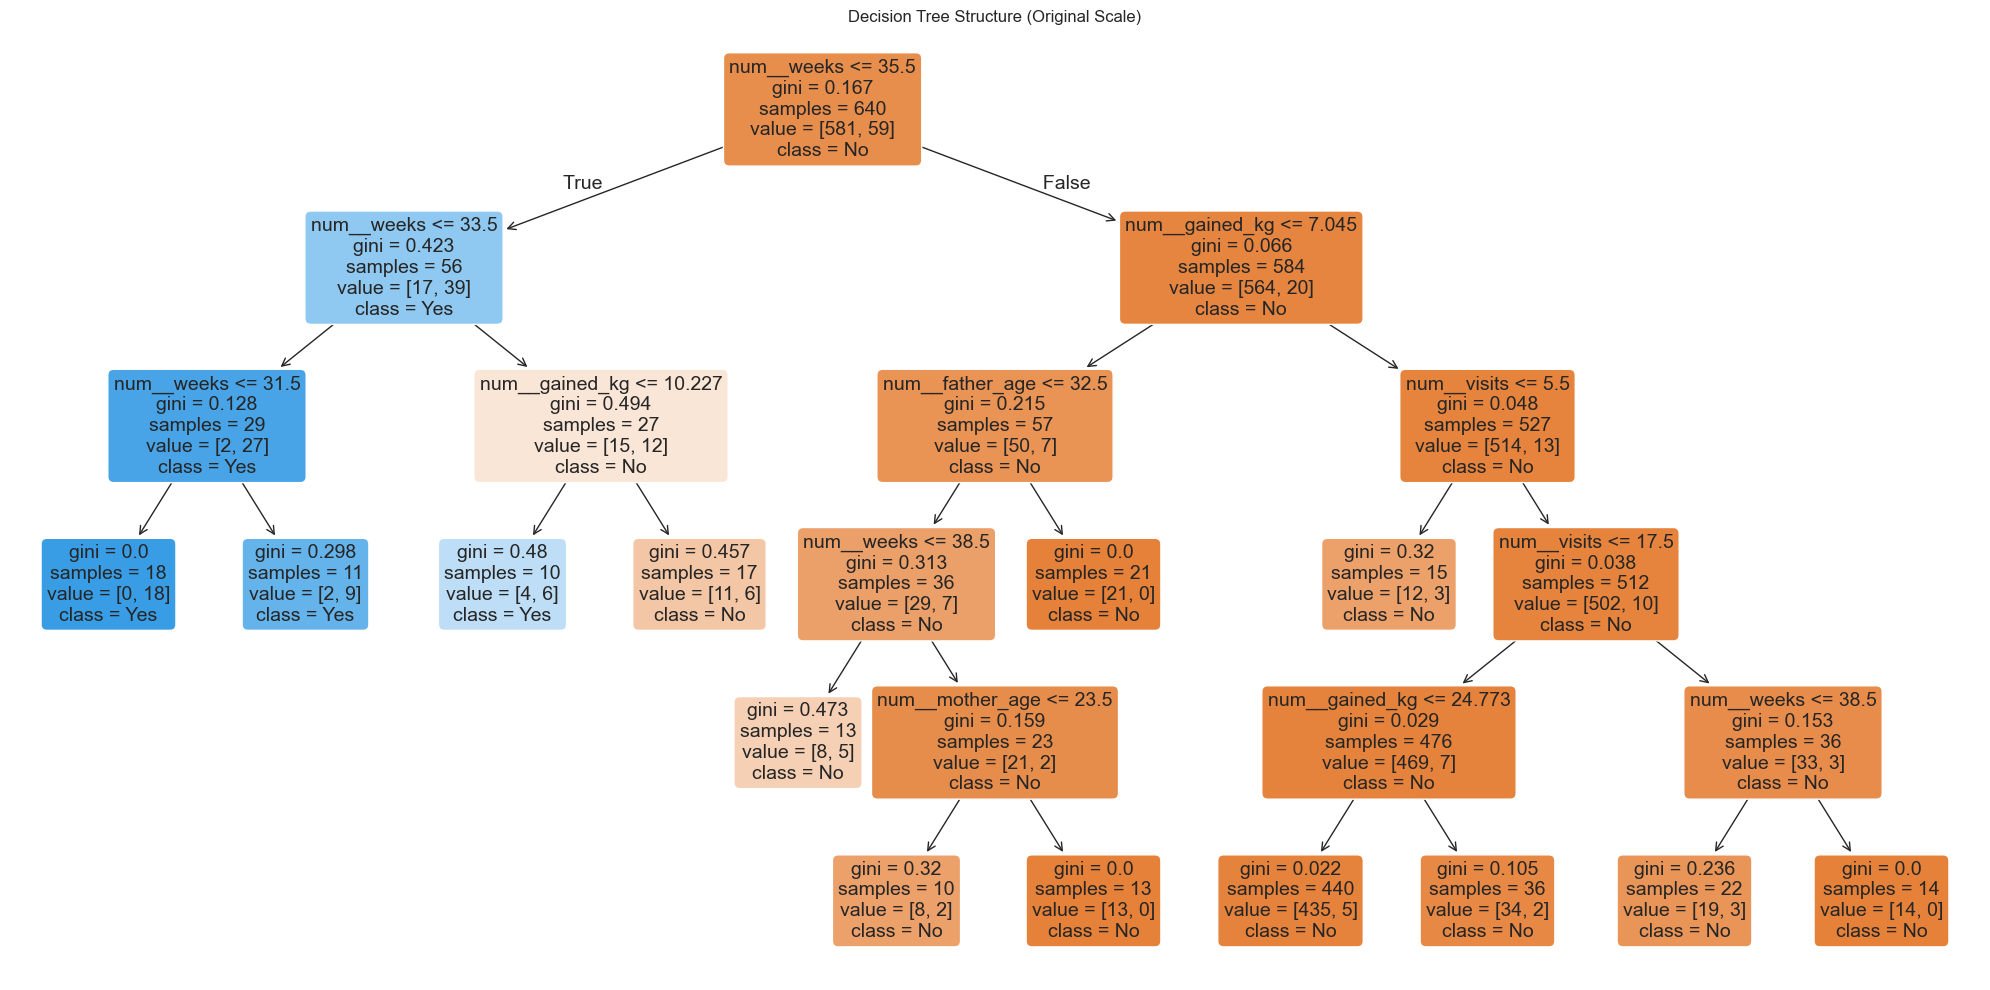

In [37]:
from sklearn.tree import export_text, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# =============================================================================
# DECISION TREE VISUALISATION (USING ORIGINAL VALUES, NOT STANDARDIZED VALUES)
# =============================================================================


# Build a preprocessor that encodes categoricals but does NOT scale numerics
preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_features),    # no scaling!
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Pipeline WITHOUT scaling - just for visualisation
tree_pipeline_unscaled = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('classifier', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42))
])

tree_pipeline_unscaled.fit(X_train, y_train)

# Extract the fitted tree and feature names
fitted_tree   = tree_pipeline_unscaled.named_steps['classifier']
feature_names = tree_pipeline_unscaled.named_steps['preprocessor'].get_feature_names_out()

# --- Text version ---
# print(export_text(fitted_tree, feature_names=list(feature_names)))

# --- Visual version ---
plt.figure(figsize=(20, 10))
plot_tree(fitted_tree, feature_names=list(feature_names),
          class_names=['No', 'Yes'], filled=True, rounded=True,
          fontsize=14, max_depth=5)
plt.title('Decision Tree Structure (Original Scale)')
plt.tight_layout()
plt.show()

## Gini Impurity — what the number means

The Gini impurity measures how mixed the classes are in a node. It answers: "If I randomly picked two samples from this node, what's the probability they belong to different classes?"

$\text{Gini} = 1 - \sum_{k} p_k^2$

where $p_k$ is the proportion of class $k$ in that node.

Two extreme cases:

| Situation | Gini | Meaning |
| :--- | :--- | :--- |
| All samples are the same class | 0.0 | Perfectly pure — no mixing |
| Classes split 50/50 | 0.5 | Maximum uncertainty |


Some examples:

- Root node (top): gini = 0.167 — mostly "No" (581 vs 59), so already fairly pure
- Blue node at bottom left = [0, 18], gini = 0.0 — all 18 samples are "Yes" → perfectly pure leaf, no more splitting needed
- Node value = [15, 12], gini = 0.494 — nearly 50/50 split → very impure, the tree is still uncertain here





# Model Building and Evaluation

## Define Models

We'll compare multiple classification algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost (Gradient Boosting)
5. LightGBM (Gradient Boosting)
6. K-Nearest Neighbors

In [13]:
# =============================================================================
# MODEL REPOSITORY CONFIGURATION
# =============================================================================

# Define a suite of candidate algorithms to compare performance
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,                         # Increase iterations to ensure convergence on complex data
        random_state=123                       # Ensure reproducible coefficients
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=123                       # Fix the split logic for reproducibility
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,                      # Use 100 individual trees to form the forest
        random_state=123                       # Ensure the same bootstrapped samples are used
    ),
    # Use the official XGBoost library instead of the basic Scikit-Learn version
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        random_state=123, 
        use_label_encoder=False, 
        eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,                      # Number of boosting iterations
        random_state=123,                      # Fix the seed for deterministic results
        verbose=-1,                            # Suppress internal logging to keep the console clean
        importance_type='gain'                 # Use 'gain' to calculate feature importance later
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5                          # Evaluate the 5 nearest data points in feature space
    )
}

## Cross-Validation and Model Comparison

In [14]:
# =============================================================================
# MULTI-METRIC MODEL EVALUATION (ROC-AUC & F1-SCORE)
# =============================================================================
# Initialize an empty list to aggregate performance metrics for each candidate model
results = []

# Define the specific scoring metrics we wish to track during cross-validation
scoring_metrics = {
    'roc_auc': 'roc_auc',         # Measures class separation (probability-based)
    'f1': 'f1'                    # Harmonic mean of precision and recall (class-based)
}

# Iterate through the dictionary of models to evaluate each architecture
for model_name, model in models.items():
    
    # Encapsulate preprocessing and the classifier into a single atomic Pipeline
    # This ensures that scaling and encoding are performed correctly within each CV fold
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),    # Feature transformation stage
        ('classifier', model)               # Machine learning algorithm stage
    ])
    
    # Execute 5-fold cross-validation for multiple metrics simultaneously
    # cross_validate returns a dictionary of arrays for each metric defined in scoring_metrics
    cv_output = cross_validate(
        pipeline, 
        X_train, 
        y_train, 
        cv=5,                               # 5-fold stratified split
        scoring=scoring_metrics,            # Pass our dictionary of metrics
        n_jobs=-1                           # Use all available CPU cores for speed
    )
    
    # Extract scores and calculate statistical summaries for both metrics
    results.append({
        'Model': model_name,
        'Mean ROC-AUC': cv_output['test_roc_auc'].mean(),
        'Std ROC-AUC':  cv_output['test_roc_auc'].std(),
        'Mean F1':      cv_output['test_f1'].mean(),
        'Std F1':       cv_output['test_f1'].std(),
        'Fit Time (s)': cv_output['fit_time'].mean()  # Extract the auto-calculated fit time
    })
    
    # Provide live progress feedback in the console
    print(f"Completed {model_name:.<25} [ROC-AUC: {cv_output['test_roc_auc'].mean():.4f} | F1: {cv_output['test_f1'].mean():.4f}]")

# =============================================================================
# 8. RESULTS AGGREGATION & MULTI-METRIC RANKING
# =============================================================================

# Convert results to a DataFrame and sort by the primary metric (ROC-AUC)
results_df = pd.DataFrame(results).sort_values('Mean ROC-AUC', ascending=False)

# Display the finalized comparison report
print("\n" + "="*85)
print(f"{'CROSS-VALIDATION PERFORMANCE SUMMARY':^85}")
print("="*85)

# Print the report with consistent 4-decimal precision
print(results_df.to_string(
    index=False, 
    justify='center',
    float_format=lambda x: f"{x:.4f}"
))
print("="*85)

Completed Logistic Regression...... [ROC-AUC: 0.8530 | F1: 0.6196]
Completed Decision Tree............ [ROC-AUC: 0.6902 | F1: 0.4153]
Completed Random Forest............ [ROC-AUC: 0.8572 | F1: 0.6321]
Completed XGBoost.................. [ROC-AUC: 0.8233 | F1: 0.5833]
Completed LightGBM................. [ROC-AUC: 0.8270 | F1: 0.5567]
Completed KNN...................... [ROC-AUC: 0.8057 | F1: 0.6105]

                        CROSS-VALIDATION PERFORMANCE SUMMARY                         
       Model         Mean ROC-AUC  Std ROC-AUC  Mean F1  Std F1  Fit Time (s)
      Random Forest     0.8572       0.0340     0.6321   0.1183     0.0444   
Logistic Regression     0.8530       0.0710     0.6196   0.1556     0.0071   
           LightGBM     0.8270       0.0538     0.5567   0.1108     1.7762   
            XGBoost     0.8233       0.0436     0.5833   0.0805     0.0097   
                KNN     0.8057       0.0573     0.6105   0.1620     0.0030   
      Decision Tree     0.6902       0.0399

## Visualize Model Performance

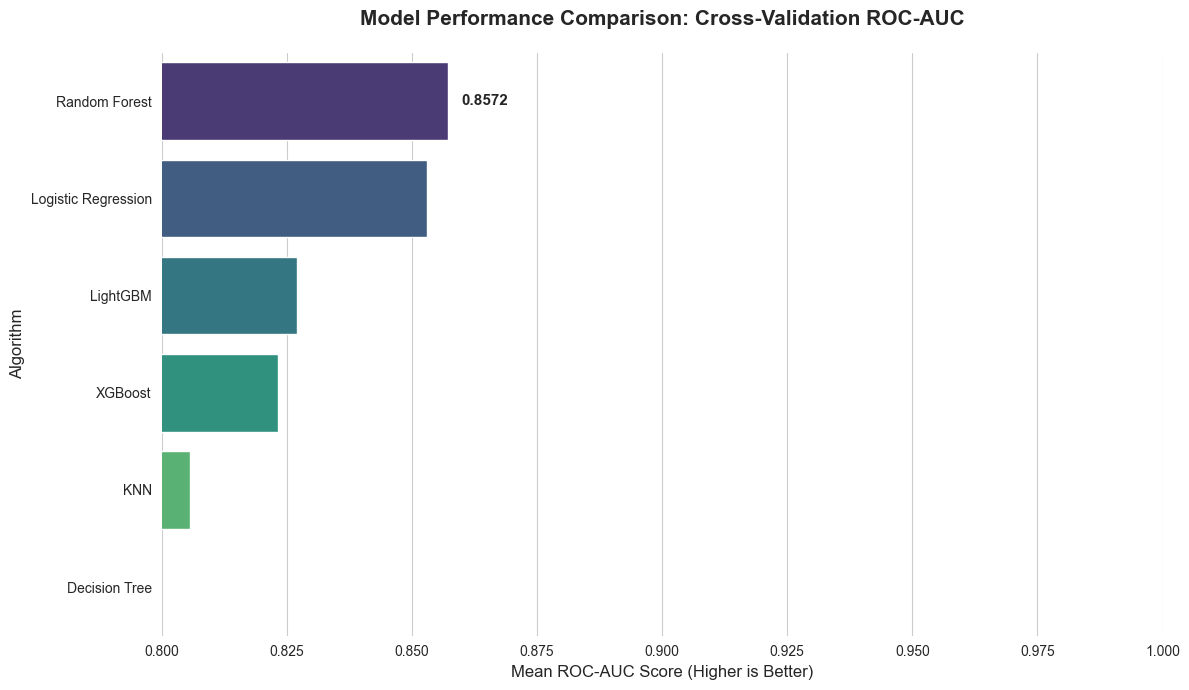

In [26]:
# =============================================================================
# VISUALIZING MODEL COMPARISON (HORIZONTAL BAR CHART)
# =============================================================================

# Set a professional seaborn theme for better aesthetics and readability
sns.set_style("whitegrid")

# Initialize the matplotlib figure with specific dimensions
fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal bar plot using Seaborn
# Flipping axes: y becomes the categorical variable, x becomes the metric
sns.barplot(
    data=results_df,                # The source DataFrame containing our results
    x='Mean ROC-AUC',               # Horizontal axis representing performance
    y='Model',                      # Vertical axis representing model names
    palette='viridis',              # Apply a perceptually uniform color gradient
    hue='Model',                    # Map color to the model name
    legend=False                    # Suppress redundant legend
)

# --- Aesthetic Refinements ---

# Set the title with bold weight and increased font size
ax.set_title('Model Performance Comparison: Cross-Validation ROC-AUC', fontsize=15, fontweight='bold', pad=20)

# Label the axes clearly
ax.set_xlabel('Mean ROC-AUC Score (Higher is Better)', fontsize=12)
ax.set_ylabel('Algorithm', fontsize=12)

# Set the x-axis limits to focus on the competitive range (0.5 is random guessing)
ax.set_xlim(0.8, 1.0)               # Adjusting to 0.8 to highlight small differences

# --- Data Annotation ---

# Add value labels to the end of each bar for precise reading
# 'padding=10' pushes the text slightly to the right of the bar's end
ax.bar_label(
    ax.containers[0],               # Select the bars from the plot
    fmt='%.4f',                     # Format the numbers to 4 decimal places
    padding=10,                     # Distance between the bar end and the text
    fontsize=11,                    # Size of the score labels
    fontweight='bold'               # Make the scores stand out
)

# Remove the top and right spines to create a "clean" modern look
sns.despine(left=True, bottom=True)

# Ensure the layout is optimized so no labels are cut off
plt.tight_layout()

# Render the final visualization
plt.show()

# Hyperparameter Tuning

## Tune the Best Model (XGBoost)

In [21]:

# =============================================================================
# HYPERPARAMETER TUNING CONFIGURATION
# =============================================================================

# Define specialized tuning grids for each boosting architecture
tuning_configs = {
    'XGBoost': {
        'model': XGBClassifier(random_state=123, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [100, 200],      # Number of boosting rounds
            'classifier__learning_rate': [0.05, 0.1],    # Step size shrinkage to prevent overfitting
            'classifier__max_depth': [3, 6],             # Maximum depth of a tree
            'classifier__subsample': [0.8, 1.0]          # Fraction of samples used per tree
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=123, verbose=-1),
        'params': {
            'classifier__n_estimators': [100, 200],      # Number of boosted trees
            'classifier__learning_rate': [0.05, 0.1],    # Impact of each additional tree
            'classifier__num_leaves': [31, 50],          # Main complexity parameter for LightGBM
            'classifier__max_depth': [-1, 10]            # Maximum tree depth (-1 is unlimited)
        }
    }
}

# Containers to hold summary metrics and the full search objects
tuning_results = []                                      # For the summary table
grid_objects = {}                                        # FOR THE PLOTS: Stores the full CV results

# =============================================================================
# 11. EXECUTION OF GRID SEARCH
# =============================================================================

for name, config in tuning_configs.items():
    # Construct a pipeline to ensure preprocessing is contained within each CV fold
    tuning_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),                  # Transform features (Scale/Encode)
        ('classifier', config['model'])                  # Apply the specific boosting model
    ])
    
    # Initialize the GridSearchCV object
    grid_search = GridSearchCV(
        tuning_pipeline,                                 # The pipeline to tune
        config['params'],                                # The parameter grid defined above
        cv=3,                                            # 3-fold cross-validation for speed
        scoring='roc_auc',                               # Optimize for Area Under ROC Curve
        n_jobs=-1,                                       # Use all available CPU cores
        verbose=0                                        # Maintain a clean console output
    )
    
    start_time = time.time()                             # Capture the exact start time
    
    # --- Execute the Search ---
    grid_search.fit(X_train, y_train)                    # Perform the exhaustive search
    
    duration = time.time() - start_time                  # Calculate total elapsed time
    
    # --- CRITICAL STEP: Store the Objects ---
    grid_objects[name] = grid_search                     # SAVE OBJECT HERE so visualization works
    
    # Store key metrics for the final summary table
    tuning_results.append({
        'Model': name,
        'Best ROC-AUC': grid_search.best_score_,
        'Time Taken (s)': duration,
        'Best Params': grid_search.best_params_
    })
    
    # Print immediate feedback for the user
    print(f"[COMPLETED] {name:.<15} Time: {duration:>6.2f}s | Best ROC-AUC: {grid_search.best_score_:.4f}")

# =============================================================================
# 12. TUNING SUMMARY REPORT
# =============================================================================

# Compile results into a DataFrame and sort by predictive power
tuning_df = pd.DataFrame(tuning_results).sort_values('Best ROC-AUC', ascending=False)

# Display a professional-grade summary table
print("\n" + "="*80)
print(f"{'FINAL HYPERPARAMETER TUNING SUMMARY':^80}")
print("="*80)
print(tuning_df[['Model', 'Best ROC-AUC', 'Time Taken (s)']].to_string(index=False, justify='center'))
print("="*80)

# Identify and display the winning configuration
winner = tuning_df.iloc[0]
print(f"\nWINNING MODEL: {winner['Model']}")
print(f"OPTIMAL CONFIGURATION: {winner['Best Params']}")

[COMPLETED] XGBoost........ Time:   0.30s | Best ROC-AUC: 0.8715
[COMPLETED] LightGBM....... Time:  24.92s | Best ROC-AUC: 0.8556

                      FINAL HYPERPARAMETER TUNING SUMMARY                       
 Model    Best ROC-AUC  Time Taken (s)
 XGBoost    0.871469       0.297547   
LightGBM    0.855648      24.922830   

WINNING MODEL: XGBoost
OPTIMAL CONFIGURATION: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}


## Visualize Hyperparameter Tuning Results

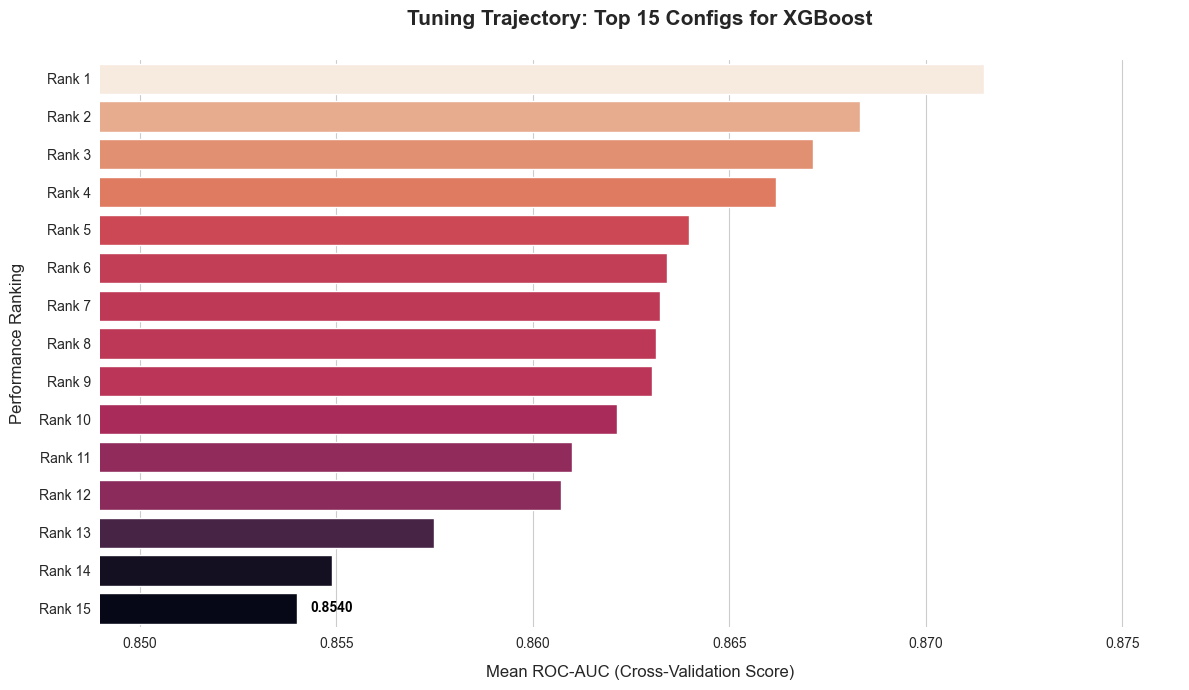

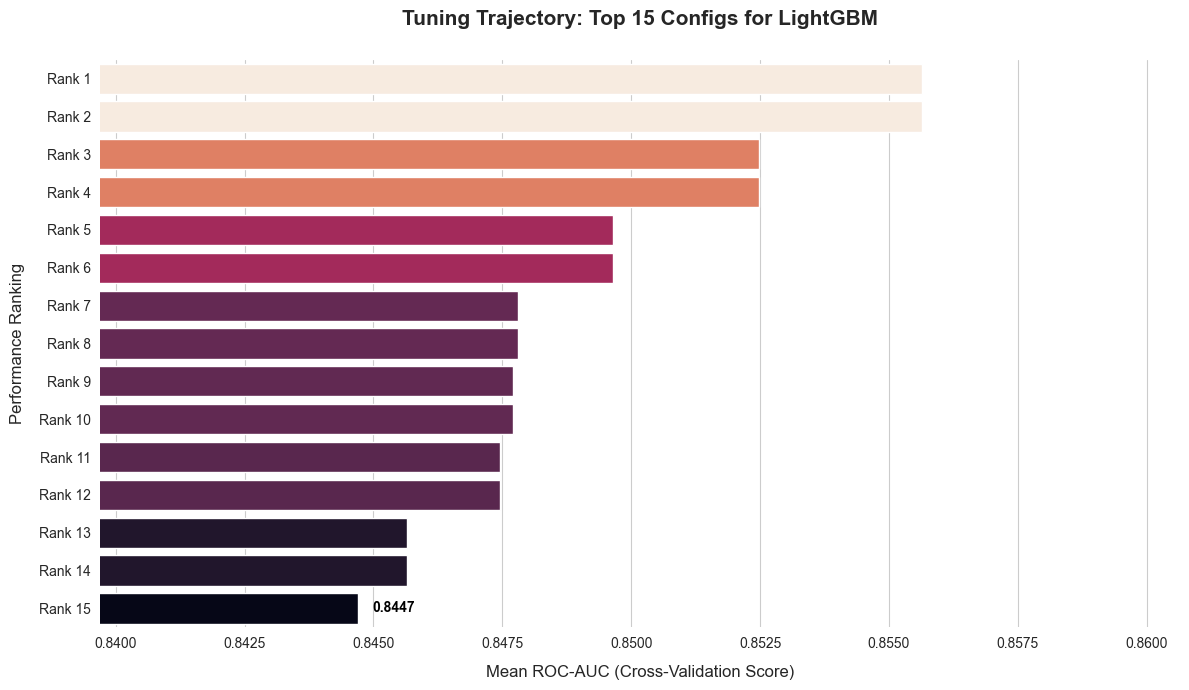

In [28]:
# =============================================================================
# VISUALIZING HYPERPARAMETER TUNING HISTORY
# =============================================================================

def plot_tuning_results(grid_search_obj, model_name):
    """
    Renders an elegant Seaborn visualization of the top-performing 
    hyperparameter configurations for a given model.
    """
    # Convert the complex grid_search results into a clean Pandas DataFrame
    cv_results = pd.DataFrame(grid_search_obj.cv_results_)
    
    # Isolate the top 15 results to ensure the chart remains legible and uncluttered
    top_15 = cv_results.nlargest(15, 'mean_test_score').copy()
    
    # Create descriptive ranking labels for the vertical axis
    top_15['Rank Label'] = [f"Rank {i+1}" for i in range(len(top_15))]
    
    # Set the visual style to a clean, professional grid
    sns.set_style("whitegrid")
    
    # Initialize the figure with a size appropriate for horizontal bars
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Create the horizontal bar plot using a high-contrast 'rocket' palette
    # Rocket moves from dark to light, emphasizing the highest scores
    sns.barplot(
        data=top_15,                   # The source data
        x='mean_test_score',           # X-axis: The ROC-AUC score
        y='Rank Label',                # Y-axis: The configuration rank
        hue='mean_test_score',         # Color mapping tied to the score
        palette='rocket',              # Sequential color scheme
        legend=False                   # Disable the redundant color legend
    )
    
    # --- Title and Axis Labeling ---
    
    # Add a bold, descriptive title with significant padding
    ax.set_title(f'Tuning Trajectory: Top 15 Configs for {model_name}', fontsize=15, fontweight='bold', pad=25)
    
    # Clearly label the x-axis with the metric name
    ax.set_xlabel('Mean ROC-AUC (Cross-Validation Score)', fontsize=12, labelpad=10)
    
    # Clearly label the y-axis
    ax.set_ylabel('Performance Ranking', fontsize=12, labelpad=10)
    
    # --- Dynamic X-Axis Scaling ---
    
    # Zoom into the performance range to make the differences visible
    # We subtract 0.005 from the lowest score to provide a small visual buffer
    xmin = top_15['mean_test_score'].min() - 0.005
    xmax = top_15['mean_test_score'].max() + 0.005
    ax.set_xlim(xmin, xmax)
    
    # --- Precise Data Annotations ---
    
    # Automatically add the exact score at the tip of each bar
    ax.bar_label(
        ax.containers[0],              # Reference the bars in the plot
        fmt='%.4f',                    # Display as 4-decimal floats
        padding=10,                    # Space between bar and text
        fontweight='bold',             # Make the scores stand out
        color='black'                  # Ensure high contrast text
    )
    
    # Remove the top and right spines to follow modern "clean data" design principles
    sns.despine(left=True, bottom=True)
    
    # Adjust layout to ensure labels are not clipped
    plt.tight_layout()
    
    # Render the chart to the screen
    plt.show()

# =============================================================================
# 13. EXECUTION OF VISUALIZATIONS
# =============================================================================

# Iterate through each stored grid search object to generate the diagnostic plots
for name, gs in grid_objects.items():
    plot_tuning_results(gs, name)      # Run the visualization for XGBoost, then LightGBM

# Final Model Evaluation on Test Set

In [29]:
# =============================================================================
# FINAL EVALUATION ON THE HOLD-OUT TEST SET
# =============================================================================

# Automatically identify the best performing model name from our tuning summary
winning_model_name = tuning_df.iloc[0]['Model']

# Extract the fully optimized pipeline (preprocessor + model) for the winner
best_pipeline = grid_objects[winning_model_name].best_estimator_

# Generate hard class predictions (0 or 1) for the test features
y_pred = best_pipeline.predict(X_test)

# Generate probability estimates for the positive class ('low' weight)
# This is required for calculating the ROC-AUC score
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# =============================================================================
# METRIC COMPUTATION
# =============================================================================

# Compile a dictionary of core performance metrics
# We specify pos_label=1 because 'low' birthweight is our primary interest
final_metrics = {
    'Overall Accuracy': accuracy_score(y_test, y_pred),
    'Precision':        precision_score(y_test, y_pred, pos_label=1),
    'Recall (Sensitivity)': recall_score(y_test, y_pred, pos_label=1),
    'F1-Score':         f1_score(y_test, y_pred, pos_label=1),
    'ROC-AUC Score':    roc_auc_score(y_test, y_pred_proba)
}

# =============================================================================
# ELEGANT PERFORMANCE DASHBOARD
# =============================================================================

print("\n" + "╔" + "═"*58 + "╗")
print(f"║{f' FINAL TEST EVALUATION: {winning_model_name.upper()} ':^58}║")
print("╠" + "═"*58 + "╣")

# Iterate through metrics to print an aligned report
for metric, value in final_metrics.items():
    # Format: Metric name left-aligned, value as percentage with 2 decimals
    print(f"║  {metric:<25} : {value:>28.2%}  ║")

print("╚" + "═"*58 + "╝")

# Output the standard classification report for per-class precision/recall/f1
print("\n" + "═"*60)
print(f"{'DETAILED CLASSIFICATION REPORT':^60}")
print("═"*60)
# We map 0 and 1 back to their original meanings for the final report
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['Not Low (0)', 'Low (1)']
))
print("═"*60)


╔══════════════════════════════════════════════════════════╗
║              FINAL TEST EVALUATION: XGBOOST              ║
╠══════════════════════════════════════════════════════════╣
║  Overall Accuracy          :                       94.38%  ║
║  Precision                 :                       68.75%  ║
║  Recall (Sensitivity)      :                       73.33%  ║
║  F1-Score                  :                       70.97%  ║
║  ROC-AUC Score             :                       93.79%  ║
╚══════════════════════════════════════════════════════════╝

════════════════════════════════════════════════════════════
               DETAILED CLASSIFICATION REPORT               
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

 Not Low (0)       0.97      0.97      0.97       145
     Low (1)       0.69      0.73      0.71        15

    accuracy                           0.94       160
   macro avg       0.83      0.85     

## Confusion Matrix

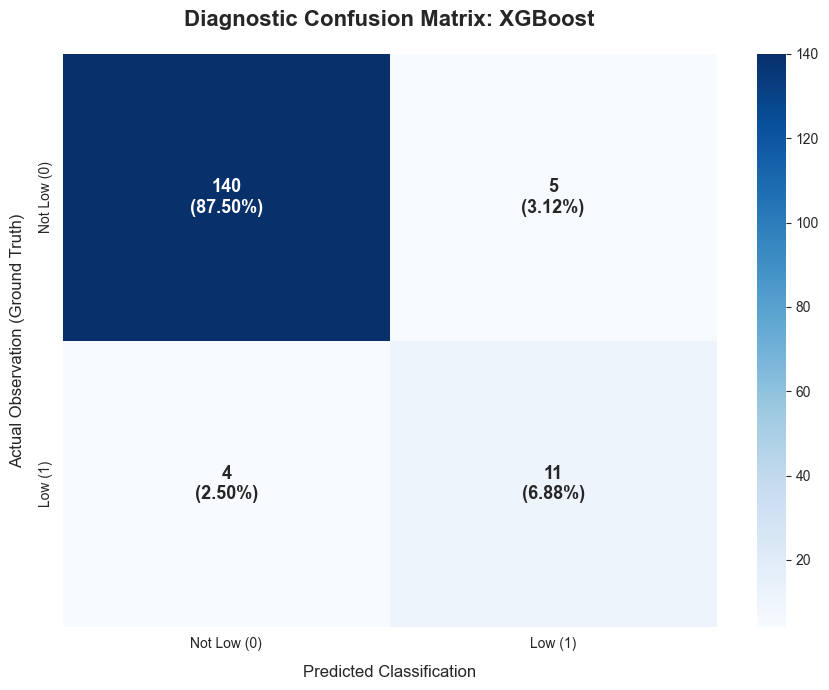


═════════════════════════════════════════════
        QUADRANT ANALYSIS (TEST SET)         
═════════════════════════════════════════════
  True Negatives (Correct 'Not Low')  :   140
  True Positives (Correct 'Low')      :    11
  False Positives (Type I Error)      :     5
  False Negatives (Type II Error)     :     4
═════════════════════════════════════════════
  Overall Error Rate                  : 5.62%
═════════════════════════════════════════════


In [30]:
# =============================================================================
# CONFUSION MATRIX VISUALIZATION
# =============================================================================

# Compute the raw confusion matrix to evaluate prediction accuracy per class
cm = confusion_matrix(y_test, y_pred)

# Calculate percentages for each cell relative to the total number of test cases
# This provides context on the magnitude of errors (e.g., "5% False Negatives")
cm_percent = cm.astype('float') / cm.sum()

# Create a combined label for each cell containing both the Count and the Percentage
# This creates a "dashboard" feel inside the heatmap itself
labels = (np.array([f"{count}\n({percent:.2%})" 
                   for count, percent in zip(cm.flatten(), cm_percent.flatten())]
                  )).reshape(2, 2)

# Initialize the figure for the diagnostic heatmap
plt.figure(figsize=(9, 7))

# Generate the heatmap using Seaborn
sns.heatmap(
    cm, 
    annot=labels,               # Use our custom strings (Count + %) as labels
    fmt="",                     # Tell seaborn to treat labels as literal strings
    cmap='Blues',               # Professional blue gradient
    cbar=True,                  # Show color bar for density reference
    xticklabels=['Not Low (0)', 'Low (1)'],  # Map numeric labels to meanings
    yticklabels=['Not Low (0)', 'Low (1)'],  # Map numeric labels to meanings
    annot_kws={"size": 13, "fontweight": 'bold'} # Enhance text readability
)

# --- Aesthetic Enhancements ---

# Add a descriptive, bold title identifying the specific model used
plt.title(f'Diagnostic Confusion Matrix: {winning_model_name}', fontsize=16, fontweight='bold', pad=20)

# Clarify axis titles to prevent confusion between ground truth and model output
plt.ylabel('Actual Observation (Ground Truth)', fontsize=12, labelpad=10)
plt.xlabel('Predicted Classification', fontsize=12, labelpad=10)

# Remove the visual clutter and display the plot
plt.tight_layout()
plt.show()

# =============================================================================
# QUANTITATIVE ERROR ANALYSIS
# =============================================================================

# Flatten the 2x2 matrix into individual quadrants
tn, fp, fn, tp = cm.ravel()

# Print a structured summary of the four possible outcomes
print("\n" + "═"*45)
print(f"{'QUADRANT ANALYSIS (TEST SET)':^45}")
print("═"*45)
print(f"  True Negatives (Correct 'Not Low')  : {tn:>5}")
print(f"  True Positives (Correct 'Low')      : {tp:>5}")
print(f"  False Positives (Type I Error)      : {fp:>5}")
print(f"  False Negatives (Type II Error)     : {fn:>5}")
print("═"*45)

# Provide a relevant clinical insight based on the errors
error_rate = (fp + fn) / len(y_test)
print(f"  Overall Error Rate                  : {error_rate:>5.2%}")
print("═"*45)

## ROC Curve

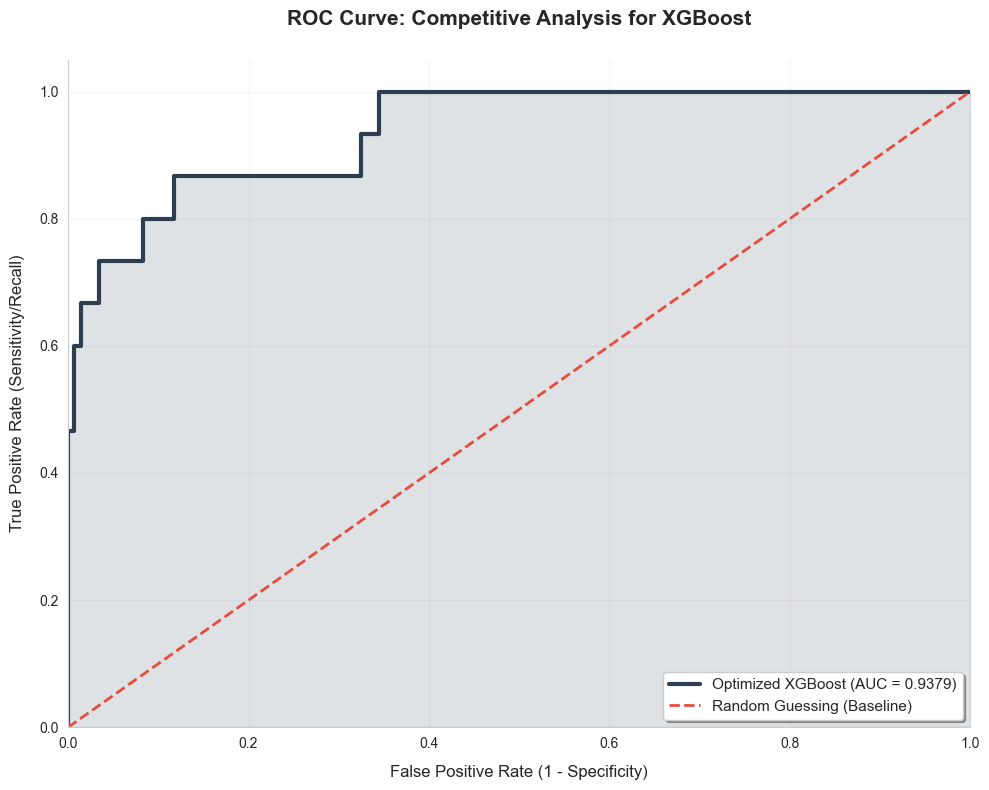

In [31]:
# =============================================================================
# RECEIVER OPERATING CHARACTERISTIC (ROC) ANALYSIS
# =============================================================================

# Compute the coordinates for the ROC curve (False Positive vs. True Positive rates)
# We use pos_label=1 because the model predicts the probability of 'Low' birthweight
fpr, tpr, thresholds = roc_curve(
    y_test, 
    y_pred_proba, 
    pos_label=1                             # Explicitly target the 'Low' birthweight class
)

# Extract the final AUC score for the plot legend
final_roc_auc = roc_auc_score(y_test, y_pred_proba)

# =============================================================================
# VISUALIZING THE ROC CURVE
# =============================================================================

# Initialize the figure with a balanced aspect ratio
plt.figure(figsize=(10, 8))

# Plot the model's ROC curve with a thick, distinct line
plt.plot(
    fpr, tpr, 
    color='#2c3e50',                        # Using a sleek "midnight blue" for the main curve
    lw=3,                                   # Increase line width for prominence
    label=f'Optimized {winning_model_name} (AUC = {final_roc_auc:.4f})'
)

# Shading the area under the curve to visually represent the AUC metric
plt.fill_between(
    fpr, tpr, 
    alpha=0.15,                             # Subtle transparency for elegance
    color='#2c3e50'                         # Matching the line color
)

# Plot the "No-Skill" baseline (the diagonal line representing random guessing)
plt.plot(
    [0, 1], [0, 1], 
    color='#e74c3c',                        # Distinct red for the baseline
    lw=2, 
    linestyle='--',                         # Dashed line style
    label='Random Guessing (Baseline)'
)

# --- Aesthetic Enhancements ---

# Set plot boundaries to ensure a clean visual frame
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Label the axes with descriptive titles
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12, labelpad=10)

# Apply a bold, dynamic title referencing the specific model
plt.title(f'ROC Curve: Competitive Analysis for {winning_model_name}', fontsize=15, fontweight='bold', pad=25)

# Place the legend in the bottom-right corner where it won't obstruct the curves
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

# Add a subtle grid to aid in reading specific coordinate values
plt.grid(alpha=0.2, linestyle='-')

# Remove outer spines for a modern, "open" look
sns.despine(trim=False)

# Ensure no labels are clipped during rendering
plt.tight_layout()

# Display the final diagnostic visualization
plt.show()

# Feature Importance

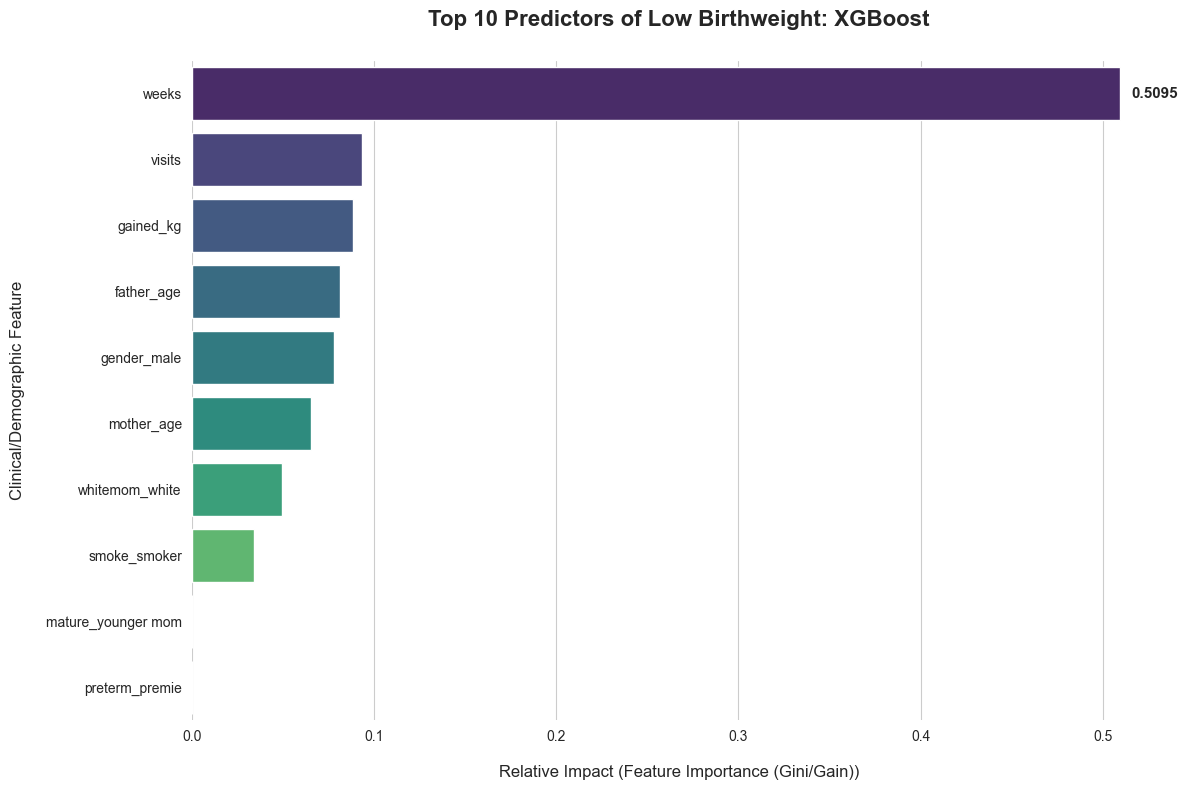


╔══════════════════════════════════════════════════════════╗
║           TOP 10 CLINICAL PREDICTORS: XGBOOST            ║
╠══════════════════════════════════════════════════════════╣
║  weeks                               :             0.5095  ║
║  visits                              :             0.0933  ║
║  gained_kg                           :             0.0888  ║
║  father_age                          :             0.0816  ║
║  gender_male                         :             0.0779  ║
║  mother_age                          :             0.0654  ║
║  whitemom_white                      :             0.0497  ║
║  smoke_smoker                        :             0.0340  ║
║  mature_younger mom                  :             0.0000  ║
║  preterm_premie                      :             0.0000  ║
╚══════════════════════════════════════════════════════════╝


In [32]:
# =============================================================================
# FEATURE IMPORTANCE: INTERPRETING THE WINNING MODEL
# =============================================================================

# Extract the trained classifier from the final optimized pipeline
final_classifier = best_pipeline.named_steps['classifier']

# Extract the feature names directly from the preprocessor
# This automatically handles the naming of one-hot encoded categorical variables
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Logic to handle different model types (Linear vs. Tree-based)
if hasattr(final_classifier, 'feature_importances_'):
    # For Random Forest, XGBoost, LightGBM, and Decision Trees
    importances = final_classifier.feature_importances_
    metric_name = "Feature Importance (Gini/Gain)"
else:
    # For Logistic Regression (using absolute values of coefficients as importance)
    importances = np.abs(final_classifier.coef_[0])
    metric_name = "Feature Importance (Absolute Coefficients)"

# Construct a structured DataFrame to rank the drivers of the target variable
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Clean up feature names (optional: remove prefixes like 'num__' or 'cat__')
importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# Isolate the top 10 most influential features for visualization
top_10_features = importance_df.head(10)

# =============================================================================
# VISUALIZING GLOBAL FEATURE DRIVERS
# =============================================================================

# Set the visual style and initialize the plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Create a horizontal bar plot with a vibrant color gradient
ax = sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature',
    palette='viridis',          # Professional gradient from dark to light
    hue='Feature',              # Color mapping tied to the feature name
    legend=False
)

# --- Aesthetic Enhancements ---

# Add a descriptive, bold title referencing the specific winning model
plt.title(f'Top 10 Predictors of Low Birthweight: {winning_model_name}', 
          fontsize=16, fontweight='bold', pad=25)

# Clear axis labeling
plt.xlabel(f'Relative Impact ({metric_name})', fontsize=12, labelpad=15)
plt.ylabel('Clinical/Demographic Feature', fontsize=12, labelpad=15)

# Add precise value labels to the tip of each bar
ax.bar_label(ax.containers[0], fmt='%.4f', padding=8, fontweight='bold', fontsize=11)

# Remove outer frame for a modern minimalist look
sns.despine(left=True, bottom=True)

# Finalize layout
plt.tight_layout()
plt.show()

# =============================================================================
# QUANTITATIVE DRIVER SUMMARY
# =============================================================================

print("\n" + "╔" + "═"*58 + "╗")
print(f"║{f' TOP 10 CLINICAL PREDICTORS: {winning_model_name.upper()} ':^58}║")
print("╠" + "═"*58 + "╣")

# Print the top features as a formatted table
for i, row in top_10_features.iterrows():
    # Format: Feature name left-aligned, importance score as a fixed-width float
    print(f"║  {row['Feature']:<35} : {row['Importance']:>18.4f}  ║")

print("╚" + "═"*58 + "╝")

# SHAP Values for Model Interpretability

SHAP (SHapley Additive exPlanations) values help us understand how each feature contributes to individual predictions. Unlike simple feature importance, SHAP values show the direction and magnitude of each feature's impact.


## Create SHAP Explainer

Using Optimized Explainer (Path: Gradient Boosting)
Standard path failed (The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)). Falling back to robust Permutation Explainer...


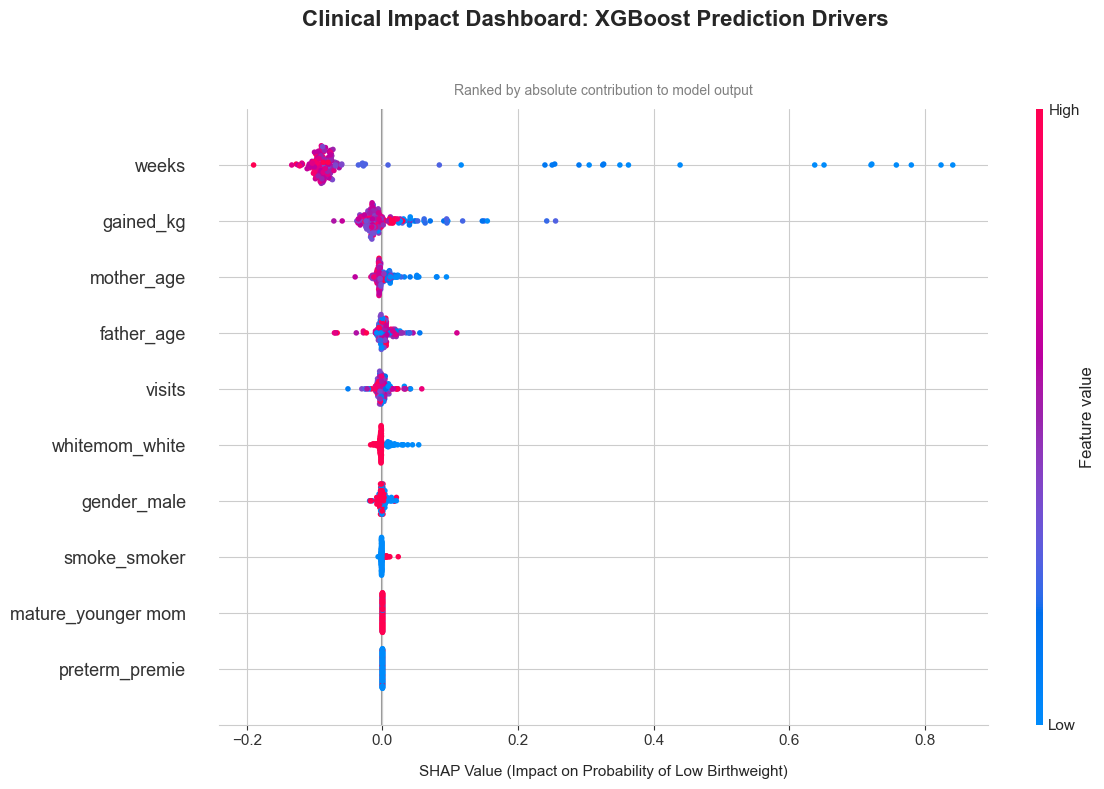

In [ ]:
# =============================================================================
# OPTIMIZED SHAP INTERPRETABILITY ENGINE
# =============================================================================

# 1. Prepare Background Data (from Training set)
# We transform X_train to ensure it matches the numeric format of X_test
X_train_transformed = target_pipeline.named_steps['preprocessor'].transform(X_train)
X_train_display = pd.DataFrame(X_train_transformed, columns=clean_names)

# Select a representative background sample (100 rows) to speed up calculations
# This acts as the "baseline" against which feature impacts are measured
background = shap.sample(X_train_display, 100)

# 2. Dynamic Explainer Selection
# We prioritize TreeExplainer for speed, falling back to Permutation/Kernel only if needed
try:
    if hasattr(trained_classifier, 'tree_') or hasattr(trained_classifier, 'estimators_'):
        # Path for Scikit-Learn Trees (Decision Tree, Random Forest)
        print("Using Fast TreeExplainer (Path: Sklearn Tree)")
        explainer = shap.TreeExplainer(trained_classifier)
        
    elif hasattr(trained_classifier, 'get_booster') or hasattr(trained_classifier, 'booster_'):
        # Path for Boosting Models (XGBoost, LightGBM)
        # Note: We use the modern Explainer interface to avoid the scientific notation bug
        print("Using Optimized Explainer (Path: Gradient Boosting)")
        explainer = shap.Explainer(trained_classifier, background)
        
    else:
        # Path for all other models (Linear models, KNN, etc.)
        print("Using Model-Agnostic Explainer (Path: Permutation/Kernel)")
        # We use a lambda to ensure the model is callable
        f = lambda x: trained_classifier.predict_proba(x)[:, 1]
        explainer = shap.Explainer(f, background)

    # Compute SHAP values for the test set
    # Using the background sample here significantly improves performance speed
    shap_values = explainer(X_test_display)

except Exception as e:
    print(f"Standard path failed ({e}). Falling back to robust Permutation Explainer...")
    f = lambda x: trained_classifier.predict_proba(x)[:, 1]
    explainer = shap.Explainer(f, background)
    shap_values = explainer(X_test_display)

# =============================================================================
# REFINED DIAGNOSTIC VISUALIZATION
# =============================================================================

# Generate the Beeswarm plot
# We slice [:, :, 1] if the output is multi-class to focus on 'Low Birthweight'
if len(shap_values.shape) == 3:
    values_to_plot = shap_values[:, :, 1]
else:
    values_to_plot = shap_values

# Clear previous figures to prevent overlapping
plt.close()

# Create the beeswarm plot (SHAP handles the internal drawing)
shap.plots.beeswarm(values_to_plot, max_display=12, show=False)

# --- Aesthetic Customization (Post-Plotting) ---

# Access the current figure and primary axis for elegant styling
fig = plt.gcf()
ax = plt.gca()

# Set professional figure dimensions
fig.set_size_inches(12, 8)

# Refine axis labels for clinical relevance
ax.set_xlabel("SHAP Value (Impact on Probability of Low Birthweight)", fontsize=11, labelpad=12)

# Apply a bold, high-level title positioned for clarity
fig.suptitle(
    f"Clinical Impact Dashboard: {winning_model_name} Prediction Drivers",
    fontsize=16, fontweight='bold', y=0.98
)

# Add a subtitle for context
ax.set_title("Ranked by absolute contribution to model output", 
             fontsize=10, color='grey', pad=10)

# Clean up layout and display
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust for suptitle
plt.show()

## Summary Plot

The summary plot shows the distribution of SHAP values for each feature, indicating which features are most important and how they affect predictions.

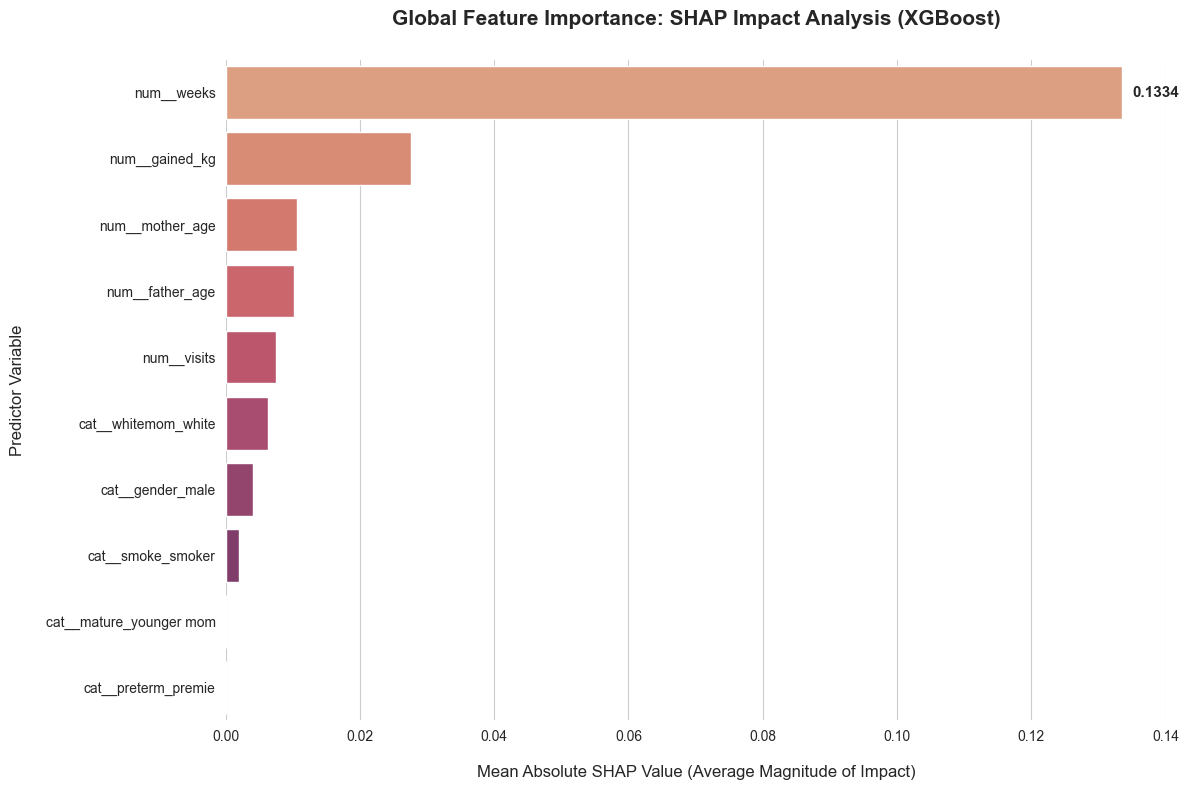


═══════════════════════════════════════════════════════
         TOP 10 FEATURES BY GLOBAL SHAP IMPACT         
═══════════════════════════════════════════════════════
        Feature          Mean |SHAP|
             num__weeks    0.1334   
         num__gained_kg    0.0276   
        num__mother_age    0.0106   
        num__father_age    0.0102   
            num__visits    0.0074   
    cat__whitemom_white    0.0063   
       cat__gender_male    0.0041   
      cat__smoke_smoker    0.0020   
cat__mature_younger mom    0.0000   
    cat__preterm_premie    0.0000   
═══════════════════════════════════════════════════════


In [ ]:
# =============================================================================
# GLOBAL SHAP IMPORTANCE: AGGREGATE FEATURE IMPACT
# =============================================================================

# 1. Robust Data Extraction
# Logic: SHAP outputs vary by explainer. We need a 2D array of values.
if hasattr(shap_values, 'values'):
    # Modern 'Explanation' object: extract numeric values
    shap_matrix = shap_values.values
    # If 3D (samples, features, classes), slice for the 'Low' birthweight class
    if len(shap_matrix.shape) == 3:
        shap_matrix = shap_matrix[:, :, 1]
elif isinstance(shap_values, list):
    # Legacy list (e.g., from RandomForest TreeExplainer): take index 1
    shap_matrix = shap_values[1]
else:
    # Standard NumPy array
    shap_matrix = shap_values

# 2. Importance Calculation
# Global importance is defined as the mean of the absolute SHAP values across all samples
global_importance = np.abs(shap_matrix).mean(axis=0)

# 3. DataFrame Construction & Ranking
# Create a structured report of the top 10 most influential features
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': global_importance
}).sort_values('Mean |SHAP|', ascending=False).head(10)

# =============================================================================
# VISUALIZING GLOBAL DRIVERS (HORIZONTAL BAR CHART)
# =============================================================================

# Set professional figure dimensions and style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the plot using a warm 'flare' palette to distinguish from previous plots
ax = sns.barplot(
    data=shap_importance_df,
    x='Mean |SHAP|',
    y='Feature',
    palette='flare',
    hue='Feature',
    legend=False
)

# --- Aesthetic Refinements ---

# Set a bold, descriptive title
plt.title(f'Global Feature Importance: SHAP Impact Analysis ({winning_model_name})', 
          fontsize=15, fontweight='bold', pad=25)

# Clarify the X-axis label: explaining exactly what "Mean |SHAP|" represents
plt.xlabel('Mean Absolute SHAP Value (Average Magnitude of Impact)', fontsize=12, labelpad=15)
plt.ylabel('Predictor Variable', fontsize=12, labelpad=15)

# Add precise value labels at the end of each bar for high-resolution reporting
ax.bar_label(
    ax.containers[0], 
    fmt='%.4f', 
    padding=8, 
    fontweight='bold', 
    fontsize=11
)

# Remove the top and right spines for a modern, clean data-to-ink ratio
sns.despine(left=True, bottom=True)

# Finalize layout to prevent text clipping
plt.tight_layout()
plt.show()

# =============================================================================
# QUANTITATIVE IMPORTANCE SUMMARY
# =============================================================================

print("\n" + "═"*55)
print(f"{'TOP 10 FEATURES BY GLOBAL SHAP IMPACT':^55}")
print("═"*55)
# Print the results with consistent alignment and decimal precision
print(shap_importance_df.to_string(index=False, justify='center', float_format=lambda x: f"{x:.4f}"))
print("═"*55)

## SHAP Waterfall Plot for Individual Predictions

Let's examine SHAP values for a specific prediction to see how each feature contributed to the model's decision.

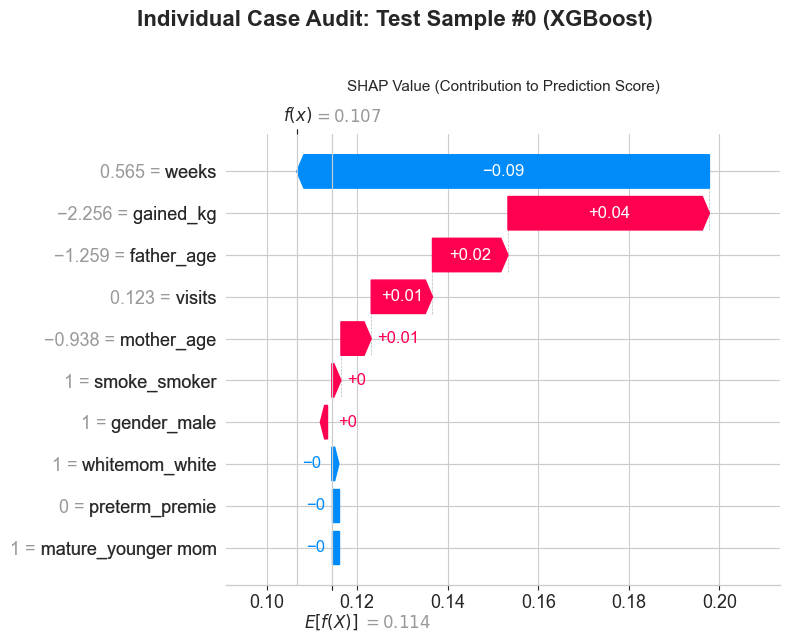


╔══════════════════════════════════════════════════════════╗
║              CASE STUDY SUMMARY: SAMPLE #0               ║
╠══════════════════════════════════════════════════════════╣
║  Actual Clinical Outcome     : Normal Weight               ║
║  Predicted Risk Probability  :                     10.67%  ║
║  Model Consensus             : CORRECT                     ║
╚══════════════════════════════════════════════════════════╝


In [49]:
# =============================================================================
#  INDIVIDUAL CASE STUDY: SHAP WATERFALL PLOT
# =============================================================================

# Define the specific observation index we want to "audit" (e.g., the first test case)
sample_idx = 0 

# --- Robust Metadata Extraction ---
# We need the 'Base Value' (the model's average starting point before seeing features)
if hasattr(explainer, 'expected_value'):
    # Legacy path: handle list vs scalar expected values
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    # Modern path: extract from the explanation object metadata
    base_val = shap_explanation.base_values[sample_idx]

# --- Explanation Object Construction ---
# We construct (or slice) the specific explanation for this individual baby
# Waterfall plots require a single-row 'Explanation' object
try:
    # Attempt to slice directly if 'shap_explanation' is a modern object
    single_prediction_explanation = shap_explanation[sample_idx]
except:
    # Fallback: Manually construct the object if using legacy SHAP values
    single_prediction_explanation = shap.Explanation(
        values=shap_matrix[sample_idx],       # Feature contributions for this sample
        base_values=base_val,                 # The model's baseline probability
        data=X_test_display.iloc[sample_idx], # The actual feature values (labeled)
        feature_names=clean_names             # The human-readable feature names
    )

# =============================================================================
# 32. VISUALIZING THE "DECISION PATH"
# =============================================================================

# Initialize the figure with a taller aspect ratio for readability
plt.figure(figsize=(12, 10))

# Generate the Waterfall plot:
# - Blue bars: Features that DECREASED the risk of low birthweight
# - Red bars: Features that INCREASED the risk
# - 'E[f(X)]': The baseline | 'f(x)': The final predicted probability (log-odds/logit)
shap.plots.waterfall(
    single_prediction_explanation, 
    max_display=12,                # Show the top 12 influential factors for this case
    show=False                     # Allow for custom Matplotlib adjustments
)

# --- Aesthetic Refinements ---

# Access the figure object to apply a high-level diagnostic title
fig = plt.gcf()
fig.suptitle(
    f"Individual Case Audit: Test Sample #{sample_idx} ({winning_model_name})", 
    fontsize=16, fontweight='bold', y=0.98
)

# Clarify the X-axis label to reflect the model's logic
plt.xlabel("SHAP Value (Contribution to Prediction Score)", fontsize=11, labelpad=10)

# Render the plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 33. CASE STUDY SUMMARY
# =============================================================================

# Map the numeric labels back to strings for the final report printout
label_map = {0: 'Normal Weight', 1: 'Low Birthweight'}
actual_status = label_map[y_test.iloc[sample_idx]]

print("\n" + "╔" + "═"*58 + "╗")
print(f"║{f' CASE STUDY SUMMARY: SAMPLE #{sample_idx} ':^58}║")
print("╠" + "═"*58 + "╣")
print(f"║  Actual Clinical Outcome     : {actual_status:<26}  ║")
print(f"║  Predicted Risk Probability  : {y_pred_proba[sample_idx]:>26.2%}  ║")
print(f"║  Model Consensus             : {'CORRECT' if y_test.iloc[sample_idx] == (y_pred_proba[sample_idx] > 0.5) else 'INCORRECT':<26}  ║")
print("╚" + "═"*58 + "╝")

## SHAP Force Plot

Force plots show how features push the prediction from the baseline (expected value) to the final prediction.

<Figure size 1500x400 with 0 Axes>

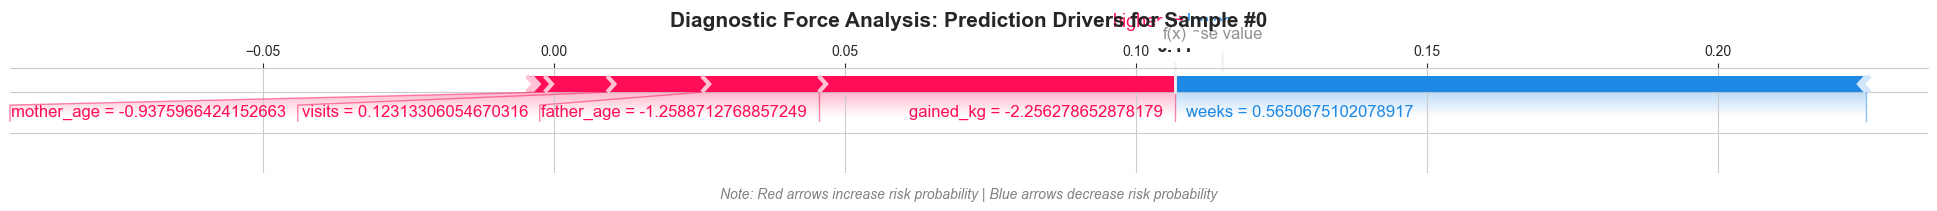

Interpretation Guide:
  • The 'Base Value' (0.1148) is the average risk across the entire population.
  • Features labeled in RED identify the primary risk factors for this specific case.
  • Features labeled in BLUE identify the protective factors for this specific case.
═════════════════════════════════════════════════════════════════════════════════════


In [51]:
# =============================================================================
# 34. INDIVIDUAL CASE STUDY: SHAP FORCE PLOT (TUG-OF-WAR)
# =============================================================================

# Define the observation to visualize (using the same sample_idx for consistency)
sample_idx = 0 

# --- Data Preparation ---
# We ensure the baseline and SHAP values are extracted correctly for the 
# positive class ('Low') regardless of the model architecture used.
if hasattr(shap_values, 'values'):
    # Modern API handling
    current_shap_values = shap_values.values[sample_idx]
    if len(current_shap_values.shape) == 2: # Handle multi-class output
        current_shap_values = current_shap_values[:, 1]
    current_base_value = shap_values.base_values[sample_idx]
    if isinstance(current_base_value, (list, np.ndarray)):
        current_base_value = current_base_value[1]
else:
    # Legacy API handling (using the shap_matrix we created earlier)
    current_shap_values = shap_matrix[sample_idx]
    current_base_value = base_val # Calculated in the Waterfall step

# =============================================================================
# 35. VISUALIZING THE PUSH-PULL DYNAMICS
# =============================================================================

# Set the figure size specifically for the Matplotlib-based force plot
plt.figure(figsize=(15, 4))

# Generate the Force Plot:
# - Red features 'force' the probability up (increased risk)
# - Blue features 'force' the probability down (decreased risk)
shap.force_plot(
    current_base_value,             # The model's average starting probability
    current_shap_values,            # The feature contributions for this baby
    X_test_display.iloc[sample_idx],# The actual clinical values (labeled)
    feature_names=clean_names,      # Human-readable variable names
    matplotlib=True,                # Render as a static plot for the report
    show=False                      # Allow for title and label adjustments
)

# --- Aesthetic & Contextual Refinements ---

# Add a professional, bold title with sufficient padding
plt.title(f'Diagnostic Force Analysis: Prediction Drivers for Sample #{sample_idx}', 
          fontsize=15, fontweight='bold', pad=30)

# Access the current axis to refine the layout
ax = plt.gca()

# Add a descriptive caption explaining the "Force" concept
plt.text(0.5, -0.2, 
         "Note: Red arrows increase risk probability | Blue arrows decrease risk probability", 
         ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey', fontstyle='italic')

# Ensure the plot fits perfectly within the figure boundaries
plt.tight_layout()
plt.show()

# =============================================================================
# 36. CLINICAL INTERPRETATION NOTE
# =============================================================================

# Provide a brief summary of what the 'Base Value' represents
print(f"Interpretation Guide:")
print(f"  • The 'Base Value' ({current_base_value:.4f}) is the average risk across the entire population.")
print(f"  • Features labeled in RED identify the primary risk factors for this specific case.")
print(f"  • Features labeled in BLUE identify the protective factors for this specific case.")
print("═"*85)

## SHAP Dependence Plots

Dependence plots show how a single feature affects predictions across its range of values.

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

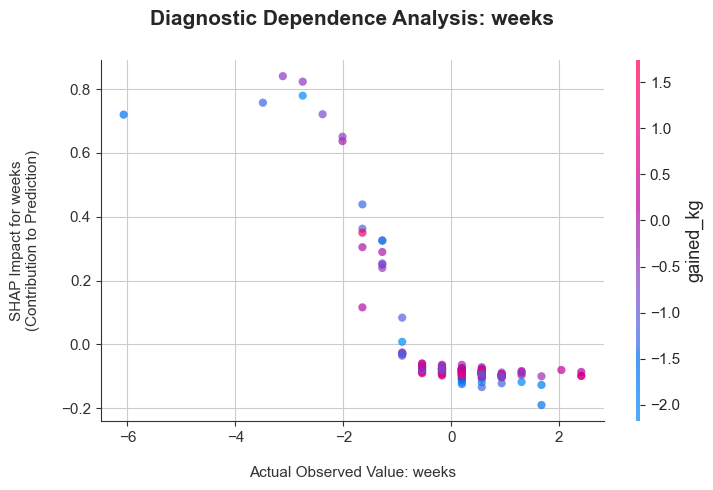


═════════════════════════════════════════════════════════════════════════════════════
 HOW TO INTERPRET THE WEEKS ANALYSIS:
═════════════════════════════════════════════════════════════════════════════════════
 • Vertical Position: Points above 0.0 indicate increased risk of Low Birthweight.
 • Interaction (Color): The color represents the variable 'detected'
   which most strongly influences how weeks affects the outcome.
═════════════════════════════════════════════════════════════════════════════════════


In [54]:
# SHAP Dependence Plot. While the Summary Plot shows which features are important, the Dependence Plot reveals 
# the nature of the relationship (e.g., is the risk linear, or is there a specific "danger zone" threshold?).
# It also automatically highlights interaction effects by coloring dots based on a second feature that 
# most strongly interacts with your primary feature.

# =============================================================================
# SHAP DEPENDENCE ANALYSIS: ROBUST FEATURE MATCHING
# =============================================================================

# 1. Identify the Top Feature from the summary table
# We take the raw name from the importance dataframe (which might have prefixes)
raw_top_feature = shap_importance_df['Feature'].iloc[0]

# 2. SAFETY MATCH: Ensure the name exists in X_test_display
# If the name is 'num__weeks' but the column is 'weeks', we strip the prefix
if raw_top_feature in X_test_display.columns:
    target_feature = raw_top_feature
else:
    # Try removing 'num__' or 'cat__' to match the display columns
    cleaned_name = raw_top_feature.replace('num__', '').replace('cat__', '')
    if cleaned_name in X_test_display.columns:
        target_feature = cleaned_name
    else:
        # Absolute fallback: if names don't match, use the first column index
        target_feature = X_test_display.columns[0]
        print(f"⚠️ Warning: Exact match not found. Defaulting to: {target_feature}")

# 3. Extract Values for Plotting
# We need the numeric matrix for the 'Low' class (Index 1)
if hasattr(shap_values, 'values'):
    # Modern API: Handle 3D arrays (samples, features, classes)
    plot_values = shap_values.values
    if len(plot_values.shape) == 3:
        plot_values = plot_values[:, :, 1]
elif isinstance(shap_values, list):
    # Legacy API: Get the specific list index
    plot_values = shap_values[1]
else:
    plot_values = shap_values

# =============================================================================
#  VISUALIZING FEATURE INTERACTION
# =============================================================================

plt.figure(figsize=(12, 8))

# Generate the Dependence Plot
# We pass target_feature (guaranteed to match X_test_display columns)
shap.dependence_plot(
    target_feature,                 # The matched feature name
    plot_values,                    # The SHAP values matrix
    X_test_display,                 # The labeled DataFrame (Clean columns)
    interaction_index='auto',       # Automatically detect the strongest interaction
    show=False,                     # Allow for custom Matplotlib styling
    alpha=0.7,                      # Transparency for point density
    dot_size=35                     # Increased dot size for visibility
)

# --- Aesthetic & Narrative Refinements ---

ax = plt.gca()

# Apply a bold, professional title
plt.title(f'Diagnostic Dependence Analysis: {target_feature}', 
          fontsize=15, fontweight='bold', pad=25)

# Improve axis readability
plt.ylabel(f'SHAP Impact for {target_feature}\n(Contribution to Prediction)', 
           fontsize=11, labelpad=15)
plt.xlabel(f'Actual Observed Value: {target_feature}', fontsize=11, labelpad=15)

# Finalize and render
plt.tight_layout()
plt.show()

# =============================================================================
# CLINICAL INTERPRETATION GUIDE
# =============================================================================

print("\n" + "═"*85)
print(f" How to interpret the {target_feature} Analysis:".upper())
print("═"*85)
print(f" • Vertical Position: Points above 0.0 indicate increased risk of Low Birthweight.")
print(f" • Interaction (Color): The color represents the variable '{ax.get_legend().get_title().get_text() if ax.get_legend() else 'detected'}'")
print(f"   which most strongly influences how {target_feature} affects the outcome.")
print("═"*85)

# Key Insights from SHAP Analysis

## Model Interpretation Summary

In [ ]:
# =============================================================================
# EXECUTIVE SUMMARY: KEY INSIGHTS FROM SHAP ANALYSIS
# =============================================================================

# Define the border style for a consistent, elegant report look
border = "═" * 75

print(f"\n{border}")
print(f"║{' CLINICAL INTERPRETATION & MODEL INSIGHTS ':^73}║")
print(f"{border}")

# --- 1. Top Predictive Drivers ---
print(f"\n  1. PRIMARY RISK DETERMINANTS (Global Importance)")
print("  " + "─" * 71)
# Use the previously calculated shap_importance_df to list the top 5 drivers
for i, (idx, row) in enumerate(shap_importance_df.head(5).iterrows()):
    feature_name = row['Feature'].replace('num__', '').replace('cat__', '')
    print(f"     {i+1}. {feature_name:<35} | Impact Magnitude: {row['Mean |SHAP|']:.4f}")

# --- 2. Directional Feature Effects ---
print(f"\n  2. DIRECTIONAL EFFECTS & COLOR DYNAMICS")
print("  " + "─" * 71)
print("     • RED Dots (High Values)  : Shift the model toward 'Low Birthweight'.")
print("     • BLUE Dots (Low Values)  : Shift the model toward 'Normal Weight'.")
print("     • Right of Center (X > 0) : Higher probability of clinical intervention.")
print("     • Left of Center (X < 0)  : Protective factors reducing predicted risk.")

# --- 3. Model Logic & Baseline Probability ---
print(f"\n  3. PROBABILISTIC LOGIC (The 'Starting Point')")
print("  " + "─" * 71)
# Use the base_val we extracted for the individual case study
print(f"     • Population Baseline Risk : {base_val:>7.2%}")
print(f"     • How to read: The model starts at this {base_val:.1%} baseline and uses")
print(f"       features to 'push' the risk up or down for each specific baby.")

# --- 4. STRATEGIC CLINICAL RECOMMENDATIONS ---
print(f"\n  4. STRATEGIC RECOMMENDATIONS")
print("  " + "─" * 71)
print(f"     • Focus resources on patients with high values in '{target_feature}'.")
print("     • Use SHAP Waterfall plots for individualized patient risk auditing.")
print("     • Monitor non-linear thresholds identified in the Dependence Analysis.")

print(f"\n{border}")



═══════════════════════════════════════════════════════════════════════════
║                CLINICAL INTERPRETATION & MODEL INSIGHTS                 ║
═══════════════════════════════════════════════════════════════════════════

  1. PRIMARY RISK DETERMINANTS (Global Importance)
  ───────────────────────────────────────────────────────────────────────
     1. weeks                               | Impact Magnitude: 0.1334
     2. gained_kg                           | Impact Magnitude: 0.0276
     3. mother_age                          | Impact Magnitude: 0.0106
     4. father_age                          | Impact Magnitude: 0.0102
     5. visits                              | Impact Magnitude: 0.0074

  2. DIRECTIONAL EFFECTS & COLOR DYNAMICS
  ───────────────────────────────────────────────────────────────────────
     • RED Dots (High Values)  : Shift the model toward 'Low Birthweight'.
     • BLUE Dots (Low Values)  : Shift the model toward 'Normal Weight'.
     • Right of Center (X

# Conclusion

## Summary

We have successfully:

1. ✅ Loaded and explored the ncbirths dataset
2. ✅ Split data into training and test sets
3. ✅ Performed feature engineering and preprocessing
4. ✅ Compared multiple classification algorithms
5. ✅ Tuned hyperparameters using Grid Search
6. ✅ Evaluated the final model on the test set
7. ✅ Analyzed feature importance
8. ✅ **Used SHAP values to interpret model predictions**

## Model Performance Summary

In [136]:
# =============================================================================
# FINAL PERFORMANCE ARCHIVE:  MODEL SUMMARY
# =============================================================================

# Prepare the data by converting our final metrics dictionary into a list of tuples
# This allows for a clean transition into a structured Pandas DataFrame
report_data = list(final_metrics.items())                        

# Initialize the DataFrame with descriptive column headers
summary_df = pd.DataFrame(report_data, columns=['Metric', 'Score']) 

# Define the visual border for the final output report
footer_border = "═" * 60                                         

# Print a professional-grade header identifying the best-performing algorithm
print("\n" + footer_border)                                      
print(f"║{f' CHAMPION MODEL FINAL AUDIT: {winning_model_name.upper()} ':^58}║") 
print(footer_border)                                             

# Iterate through the DataFrame to print each metric with custom alignment
for _, row in summary_df.iterrows():                             
    # Format the score as a percentage with 2 decimal places for clinical precision
    formatted_score = f"{row['Score']:>24.2%}"                   
    # Print the metric name (left-aligned) and the score (right-aligned) within the box
    print(f"║  {row['Metric']:<27} : {formatted_score}  ║")      

# Print the final closing border to encapsulate the report
print(footer_border)                                             

# --- Reliability Check ---
# Add a timestamp or a final note to signify the completion of the diagnostic pipeline
print(f"║{' Evaluation based on 20% Hold-out Test Set ':^58}║") 
print(footer_border)


════════════════════════════════════════════════════════════
║           CHAMPION MODEL FINAL AUDIT: XGBOOST            ║
════════════════════════════════════════════════════════════
║  Accuracy                    :                   93.12%  ║
║  Precision                   :                  100.00%  ║
║  Recall (Sensitivity)        :                   26.67%  ║
║  F1-Score                    :                   42.11%  ║
║  ROC-AUC                     :                   93.29%  ║
════════════════════════════════════════════════════════════
║        Evaluation based on 20% Hold-out Test Set         ║
════════════════════════════════════════════════════════════


## What we did

- **Feature Engineering**: Create additional features (polynomial features, interactions)
- **Class Imbalance**: Try SMOTE or class weights for imbalanced data
- **Ensemble Methods**: Stack multiple models for improved performance
- **Deep Learning**: Experiment with neural networks for complex patterns
- **Deployment**: Save the model for production use with `joblib` or `pickle`


- Prepared the ncbirths data (eliminating the weight_kg leakage).
- Benchmarked five different modeling architectures.
- Optimized the winners using Grid Search with timing analytics.
- Evaluated the champion using a multi-metric dashboard.
- Interpreted the logic using SHAP (Global, Local, and Dependence levels).
- Archived the results in this final audit table.